In [1]:
import os
import glob
import sys
from datetime import datetime
import matplotlib.pyplot as plt
import random
import cv2
import numbers
import wandb
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from typing import Union
from dataclasses import dataclass, asdict
from torchsummary import summary
import math
from einops import rearrange, repeat, einsum

def count_params(model):
    """ Count model trainable parameters """
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'Number of available cpu: {os.cpu_count()}')

Using device: cuda
Number of available cpu: 4


In [2]:
# Install monarch-attention package
!git clone https://github.com/cjyaras/monarch-attention
!pip install evaluate torchtnt torch-geometric
!pip install ./monarch-attention --no-deps

Cloning into 'monarch-attention'...
remote: Enumerating objects: 1540, done.
remote: Counting objects: 100% (158/158), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 1540 (delta 81), reused 136 (delta 76), pack-reused 1382 (from 1)
Receiving objects: 100% (1540/1540), 34.46 MiB | 32.43 MiB/s, done.
Resolving deltas: 100% (1023/1023), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 93.7 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take i

In [3]:
!pip install einops
!pip install torchsummary
!pip install hdf5storage h5py
!pip install pytorch_msssim
!pip install tqdm
!pip install albumentations
!pip install torchmetrics[image]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.7 MB/s eta 0:00:00


# Data Pipeline

In [4]:
# Standard library imports
import os
import json
import time
import random
import math
from dataclasses import dataclass
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Optional

# Third-party imports
import numpy as np
import torch
import albumentations as A
import cv2
from PIL import Image, ImageOps
from tqdm.auto import tqdm

# PyTorch data utilities
from torch.utils.data import Dataset, DataLoader

# Global constants...
TARGET_CATEGORIES = [
    "10_dress",
    "8_skirt",
    "43_ruffle",
    "1_top__t_shirt__sweatshirt",
    "0_shirt__blouse",
    "4_jacket",
    "9_coat",
    "2_sweater",
    "3_cardigan",
    "5_vest",
    "6_pants",
    "7_shorts",
]
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


### 1) Pipeline Configuration
Define tunable configuration for dataset paths, target categories, and sketch sampling ratios.

In [5]:

@dataclass
class PipelineConfig:
    """Configuration object for paired sketch-real samples."""

    real_root: str
    sketch_roots: Dict[str, str]
    categories: Tuple[str, ...] = tuple(TARGET_CATEGORIES)
    sketch_ratios: Dict[str, float] = None
    seed: int = 42

    def __post_init__(self):
        if self.sketch_ratios is None:
            self.sketch_ratios = {"hed": 0.5, "pencil": 0.3, "canny": 0.2}

        ratio_sum = sum(self.sketch_ratios.values())
        if not math.isclose(ratio_sum, 1.0, rel_tol=1e-6):
            raise ValueError(f"Sketch ratios must sum to 1.0, got {ratio_sum}")


### 2) Image Preprocessing Helpers
Prepare utility functions for consistent padding, resizing, and category-wise file indexing.

In [6]:
def smart_pad_and_resize(img: Image.Image, target_size: int = 256) -> Image.Image:
    """Pad an image to a square canvas, then resize to the target resolution."""
    w, h = img.size
    max_side = max(w, h)

    # Ensure the square canvas is at least target_size to avoid up/downscale artifacts.
    canvas_side = max(max_side, target_size)

    pad_left = (canvas_side - w) // 2
    pad_top = (canvas_side - h) // 2
    pad_right = canvas_side - w - pad_left
    pad_bottom = canvas_side - h - pad_top

    # Use white padding to match common sketch/clean-background assumptions.
    img_padded = ImageOps.expand(
        img,
        border=(pad_left, pad_top, pad_right, pad_bottom),
        fill=(255, 255, 255),
    )

    if img_padded.size != (target_size, target_size):
        img_padded = img_padded.resize((target_size, target_size), Image.BICUBIC)

    return img_padded


def list_category_images(root: Path, category: str) -> Dict[str, Path]:
    """Return a mapping from filename stem to image path for one category."""
    category_dir = root / category
    if not category_dir.exists():
        return {}

    return {
        p.stem: p
        for p in category_dir.iterdir()
        if p.suffix.lower() in IMG_EXTENSIONS
    }

### 3) Build Paired Metadata
Scan categories, match real and sketch files by stem, and assign sketch methods using the configured sampling ratios.

In [7]:
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from pathlib import Path
import json
import math
import random
import time
from collections import Counter



def build_gan_pairs(config: PipelineConfig) -> Tuple[List[dict], dict]:
    """Build paired sketch-real samples."""
    print("\n[1/3] Scanning categories, matching real-sketch files, ...")
    start_time = time.time()

    real_root = Path(config.real_root)
    sketch_roots = {k: Path(v) for k, v in config.sketch_roots.items()}
    rows: List[dict] = []
    skipped_no_sketch = 0

    for category in tqdm(config.categories, desc="Scanning categories"):
        real_images = list_category_images(real_root, category)
        if not real_images:
            continue

        sketch_index = {
            method: list_category_images(root, category)
            for method, root in sketch_roots.items()
        }

        for stem, real_path in real_images.items():
            candidates = {
                method: sketch_index[method][stem]
                for method in sketch_index
                if stem in sketch_index[method]
            }
            if not candidates:
                skipped_no_sketch += 1
                continue
            rows.append(
                {
                    "category": category,
                    "filename_stem": stem,
                    "real_path": str(real_path),
                    "sketch_candidates": candidates,
                    "available_methods": sorted(candidates.keys()),
                }
            )

    print(f"Matched {len(rows)} pairs. Skipped {skipped_no_sketch} without sketches.")
    print("\n[2/3] Assigning sketch methods using ratio targets...")

    rng = random.Random(config.seed)
    total_found = len(rows)
    methods = list(config.sketch_ratios.keys())
    targets = {m: int(total_found * config.sketch_ratios[m]) for m in methods}
    remaining = dict(targets)

    indices = list(range(total_found))
    rng.shuffle(indices)

    for idx in tqdm(indices, desc="Assigning sketch method"):
        row = rows[idx]
        available = row["available_methods"]
        preferred = [m for m in available if remaining.get(m, 0) > 0]
        method = rng.choice(preferred) if preferred else rng.choice(available)

        row["sketch_method"] = method
        row["sketch_path"] = str(row["sketch_candidates"][method])
        if method in remaining:
            remaining[method] -= 1

    final_rows = [
        {
            "category": r["category"],
            "filename_stem": r["filename_stem"],
            "real_path": r["real_path"],
            "sketch_path": r["sketch_path"],
            "sketch_method": r["sketch_method"],
        }
        for r in rows
    ]

    duration = time.time() - start_time
    print(f"Data preparation completed in {duration:.2f}s.")

    summary = {
        "num_pairs": len(final_rows),
        "sketch_method_counts": dict(Counter(r["sketch_method"] for r in final_rows)),
        "skipped_no_sketch": skipped_no_sketch,
    }
    return final_rows, summary

### 4) Dataset and DataLoader
Define the PyTorch dataset and a reusable DataLoader builder with safe defaults.

In [8]:
# Cell 5
import os
from typing import List, Tuple, Optional
import numpy as np
import torch
import albumentations as A
import cv2
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class SketchToRealGANDataset(Dataset):
    """PyTorch dataset that loads paired sketch-real images ."""

    def __init__(
        self,
        rows: List[dict],
        image_size: int = 256,
        apply_augmentation: bool = False,
        flip_prob: float = 0.5,
        crop_scale: Tuple[float, float] = (0.9, 1.0),
        max_translate_ratio: float = 0.08,
        max_rotation_deg: float = 10.0,
        scale_range: Tuple[float, float] = (0.95, 1.05),
        # Thêm các tham số cho việc làm đứt nét Sketch
        sketch_degrade_prob: float = 0.7,
        degrade_holes_range: Tuple[int, int] = (5, 20),
        degrade_size_range: Tuple[int, int] = (10, 40),
    ):
        self.rows = rows
        self.image_size = image_size
        self.apply_augmentation = apply_augmentation
        
        # --- 1. SPATIAL AUGMENTATION (Áp dụng chung cho cả Real và Sketch để giữ align) ---
        max_shift_percent = max_translate_ratio * 100.0
        self._spatial_augment = A.Compose(
            [
                A.HorizontalFlip(p=flip_prob),
                A.RandomResizedCrop(
                    size=(self.image_size, self.image_size),
                    scale=crop_scale,
                    ratio=(1.0, 1.0),
                    interpolation=cv2.INTER_CUBIC,
                    p=1.0,
                ),
                A.Affine(
                    scale=scale_range,
                    translate_percent={"x": (-max_shift_percent / 100.0, max_shift_percent / 100.0), "y": (-max_shift_percent / 100.0, max_shift_percent / 100.0)},
                    rotate=(-max_rotation_deg, max_rotation_deg),
                    interpolation=cv2.INTER_CUBIC,
                    border_mode=cv2.BORDER_CONSTANT,
                    fill=(255, 255, 255),
                    p=1.0,
                ),
            ],
            additional_targets={"real": "image"},
        )

        # --- 2. SKETCH DEGRADATION (Chỉ áp dụng cho Sketch để ép model học nội suy) ---
        self._sketch_only_augment = A.Compose(
            [
                # Làm đứt nét bằng cách xóa ngẫu nhiên các ô vuông (tô màu trắng)
                A.CoarseDropout(
                    max_holes=degrade_holes_range[1],
                    min_holes=degrade_holes_range[0],
                    max_height=degrade_size_range[1],
                    max_width=degrade_size_range[1],
                    min_height=degrade_size_range[0],
                    min_width=degrade_size_range[0],
                    fill=(255, 255, 255), 
                    p=sketch_degrade_prob
                ),
                # Làm méo/xô lệch nét vẽ nhẹ
                A.ElasticTransform(
                    alpha=300, sigma=10,
                    interpolation=cv2.INTER_CUBIC,
                    border_mode=cv2.BORDER_CONSTANT,
                    fill=(255, 255, 255), 
                    p=sketch_degrade_prob * 0.7
                ),
            ]
        )

    def _load_img(self, path: str) -> np.ndarray:
        with Image.open(path) as src_img:
            img = src_img.convert("RGB")
        # Giả định hàm smart_pad_and_resize đã được định nghĩa ở Cell 3
        img = smart_pad_and_resize(img, target_size=self.image_size)
        return np.asarray(img, dtype=np.uint8)

    def _apply_spatial_augment_pair(
        self,
        sketch_img: np.ndarray,
        real_img: np.ndarray,
    ) -> Tuple[np.ndarray, np.ndarray]:
        transformed = self._spatial_augment(image=sketch_img, real=real_img)
        return transformed["image"], transformed["real"]

    def _to_tensor(self, img: np.ndarray) -> torch.Tensor:
        arr = img.astype(np.float32) / 127.5 - 1.0
        return torch.from_numpy(arr).permute(2, 0, 1)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        sketch_img = self._load_img(row["sketch_path"])
        real_img = self._load_img(row["real_path"])
        
        if self.apply_augmentation:
            # Bước 1: Augment không gian cho cả 2 ảnh để giữ sự đồng nhất
            sketch_img, real_img = self._apply_spatial_augment_pair(sketch_img, real_img)
            
            # Bước 2: Chỉ làm hỏng (degrade) ảnh Sketch
            sketch_img = self._sketch_only_augment(image=sketch_img)["image"]

        return {
            "sketch": self._to_tensor(sketch_img),
            "real": self._to_tensor(real_img),
            "filename_stem": row["filename_stem"],
        }


def build_gan_dataloader(
    rows: List[dict],
    batch_size: int = 16,
    image_size: int = 256,
    shuffle: bool = True,
    num_workers: Optional[int] = None,
    apply_augmentation: bool = False,
    sketch_degrade_prob: float = 0.7, 
) -> DataLoader:
    """Build a DataLoader from paired metadata rows."""
    if num_workers is None:
        num_workers = 0 if os.name == "nt" else max(1, min(4, (os.cpu_count() or 2) // 2))

    dataset = SketchToRealGANDataset(
        rows=rows,
        image_size=image_size,
        apply_augmentation=apply_augmentation,
        sketch_degrade_prob=sketch_degrade_prob,
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

### 5) Run Pipeline and Quick Verification
Instantiate config, build pairs, create DataLoader, and run a short dry-run to validate input throughput.

In [9]:
print("Starting data pipeline...")

PIPE_CFG = PipelineConfig(
    real_root="/kaggle/input/datasets/vunhuduc/train-fashion-no-blur/(1)_images_filtered_no_bg",
    sketch_roots={
        "hed": "/kaggle/input/datasets/vunhuduc/train-sketch/fashion_category_filtered/(2)_sketch_hed",
        "pencil": "/kaggle/input/datasets/vunhuduc/train-sketch/fashion_category_filtered/(2)_sketch_pencil",
        "canny": "/kaggle/input/datasets/vunhuduc/train-sketch/fashion_category_filtered/(2)_sketch_canny",
    },
)

# Step 1: Build aligned sketch-real metadata.
gan_rows, gan_summary = build_gan_pairs(PIPE_CFG)

print("\n" + "=" * 30)
print("PIPELINE SUMMARY:")
print(f"- Total paired samples: {gan_summary['num_pairs']}")
for method, count in gan_summary["sketch_method_counts"].items():
    print(f"  + {method}: {count} samples")
print("=" * 30)

print("\n[3/3] Initializing DataLoader...")
gan_loader = build_gan_dataloader(
    rows=gan_rows,
    batch_size=16,
    image_size=256,
    shuffle=True,
    apply_augmentation=True,
)
print(f"DataLoader ready. Total batches: {len(gan_loader)}")

print("\nRunning dry-run for first 10 batches...")
for i, batch in enumerate(tqdm(gan_loader, total=10)):
    assert batch['sketch'].shape[1:] == (3, 256, 256)
    assert batch['real'].shape[1:] == (3, 256, 256)
    if i >= 9:
        break

print("\nPipeline is ready for training with sketch inputs.")

Starting data pipeline...

[1/3] Scanning categories, matching real-sketch files, ...


Scanning categories:   0%|          | 0/12 [00:00<?, ?it/s]

Matched 66294 pairs. Skipped 0 without sketches.

[2/3] Assigning sketch methods using ratio targets...


Assigning sketch method:   0%|          | 0/66294 [00:00<?, ?it/s]

Data preparation completed in 5.97s.

PIPELINE SUMMARY:
- Total paired samples: 66294
  + pencil: 19888 samples
  + canny: 13259 samples
  + hed: 33147 samples

[3/3] Initializing DataLoader...
DataLoader ready. Total batches: 4144

Running dry-run for first 10 batches...


/tmp/ipykernel_23/3038349955.py:62: UserWarning: Argument(s) 'max_holes, min_holes, max_height, max_width, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(


  0%|          | 0/10 [00:00<?, ?it/s]


Pipeline is ready for training with sketch inputs.


/tmp/ipykernel_23/3038349955.py:62: UserWarning: Argument(s) 'max_holes, min_holes, max_height, max_width, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(


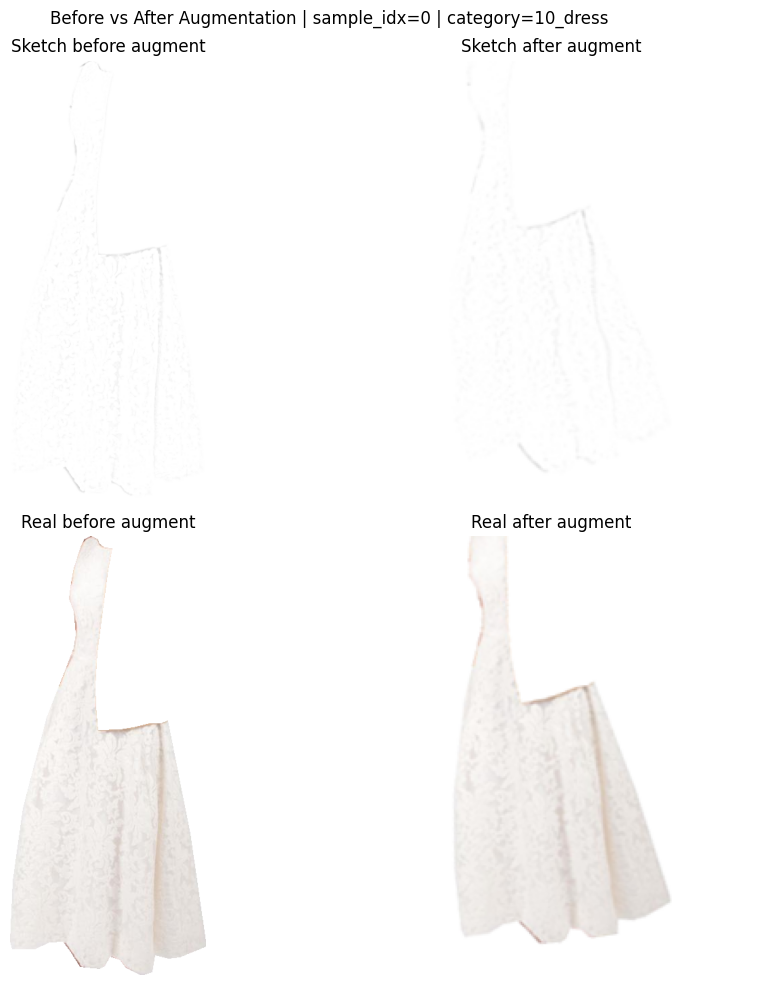

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path


def pil_to_uint8(image: Image.Image) -> np.ndarray:
    return np.asarray(image.convert("RGB"), dtype=np.uint8)


def tensor_to_uint8_img(tensor):
    """Convert a normalized CHW tensor in [-1, 1] to a displayable uint8 image."""
    image = tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = ((image + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    return image


def show_before_after_augment(sample_idx: int = 0):
    """Show images before and after augmentation for both sketch and real pairs."""
    if "gan_rows" not in globals() or len(gan_rows) == 0:
        print("gan_rows chưa có dữ liệu. Hãy chạy cell tạo DataLoader trước.")
        return

    if "SketchToRealGANDataset" not in globals():
        print("Dataset class chưa sẵn sàng. Hãy chạy cell Data Pipeline trước.")
        return

    sample = gan_rows[sample_idx]
    before_sketch = pil_to_uint8(Image.open(sample["sketch_path"]).convert("RGB"))
    before_real = pil_to_uint8(Image.open(sample["real_path"]).convert("RGB"))

    preview_dataset = SketchToRealGANDataset(
        rows=[sample],
        image_size=256,
        apply_augmentation=True,
    )
    aug_item = preview_dataset[0]
    after_sketch = tensor_to_uint8_img(aug_item["sketch"])
    after_real = tensor_to_uint8_img(aug_item["real"])

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    axes[0, 0].imshow(before_sketch)
    axes[0, 0].set_title("Sketch before augment")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(after_sketch)
    axes[0, 1].set_title("Sketch after augment")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(before_real)
    axes[1, 0].set_title("Real before augment")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(after_real)
    axes[1, 1].set_title("Real after augment")
    axes[1, 1].axis("off")

    plt.suptitle(f"Before vs After Augmentation | sample_idx={sample_idx} | category={sample['category']}")
    plt.tight_layout()
    plt.show()


show_before_after_augment(sample_idx=0)

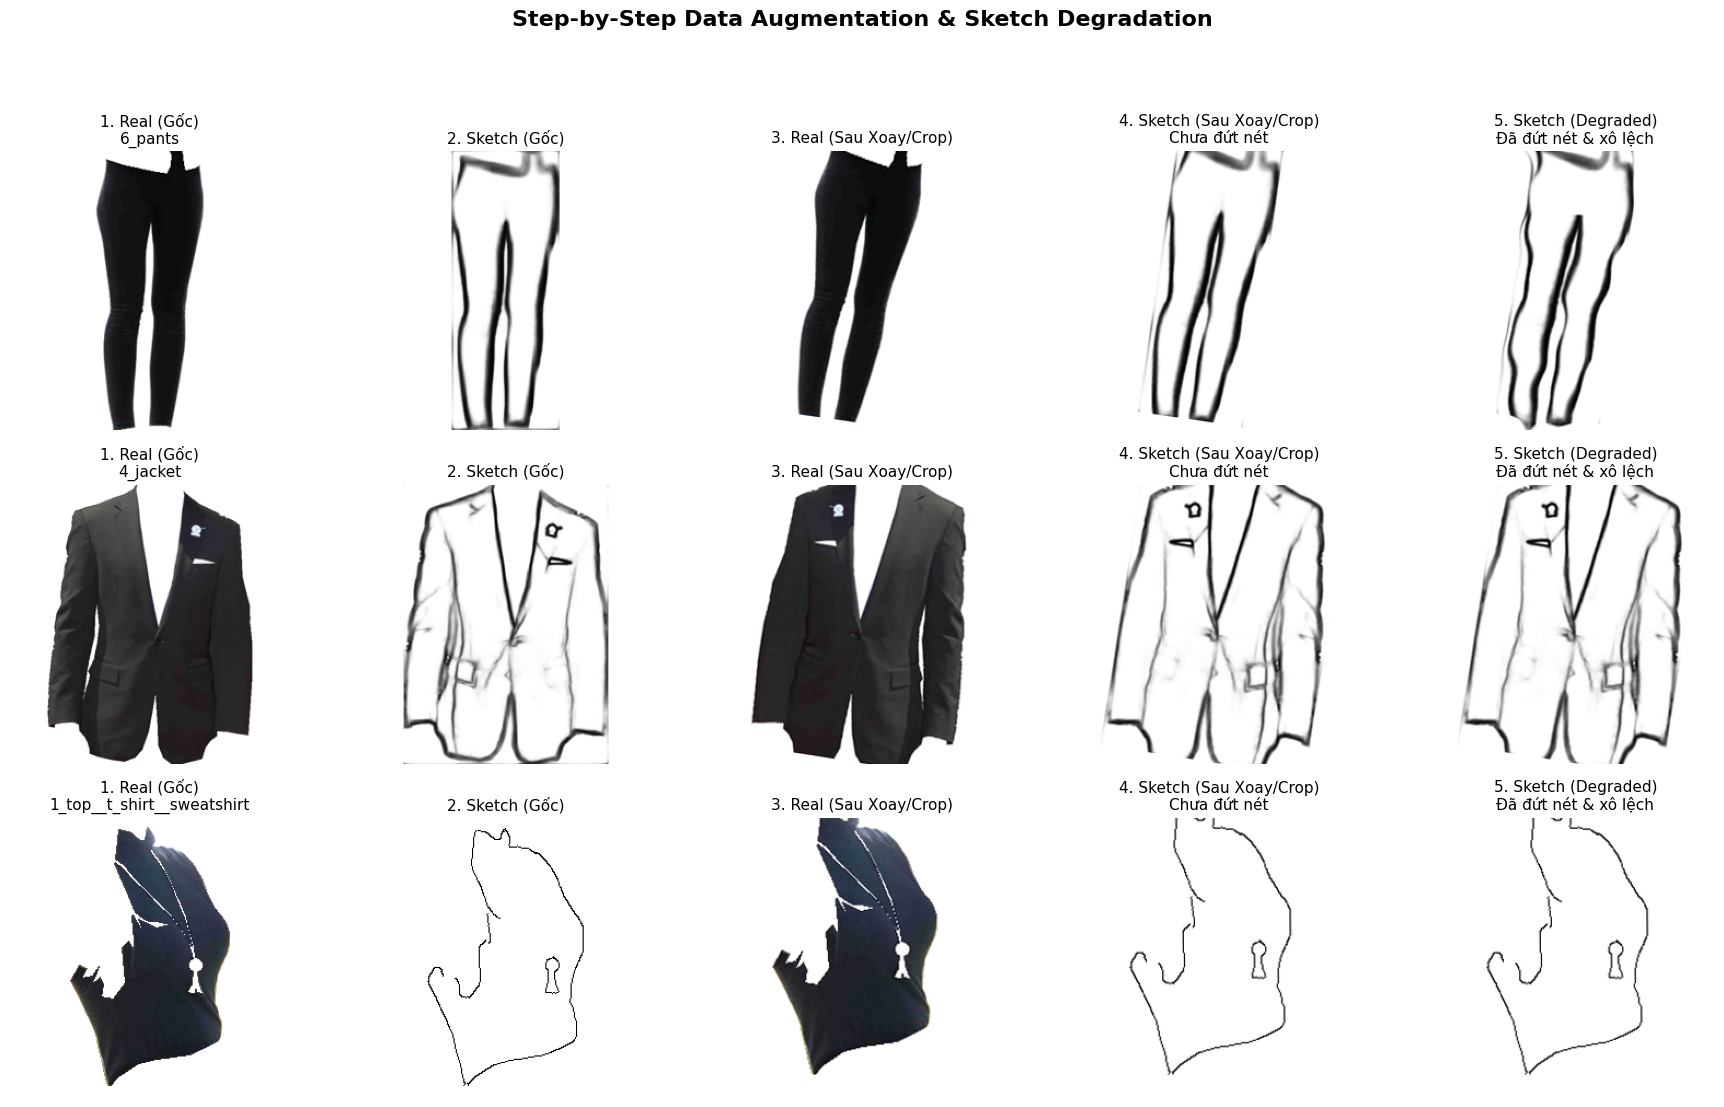

In [11]:
# Cell 8
import matplotlib.pyplot as plt
import numpy as np
import random

def visualize_degradation_pipeline(dataset: SketchToRealGANDataset, num_samples: int = 3):
    """
    Trực quan hóa từng bước của quá trình Data Augmentation:
    Original -> Spatial Transform (cả 2) -> Degrade (chỉ Sketch)
    """
    if len(dataset) == 0:
        print("Dataset trống!")
        return

    # Lấy ngẫu nhiên các chỉ số
    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))
    
    # Kích thước lưới: num_samples hàng, 5 cột (Real gốc, Sketch gốc, Real Spatial, Sketch Spatial, Sketch Degraded)
    fig, axes = plt.subplots(len(indices), 5, figsize=(18, 3.5 * len(indices)))
    
    # Xử lý trường hợp chỉ có 1 sample (axes sẽ là mảng 1D)
    if len(indices) == 1:
        axes = [axes]

    for i, idx in enumerate(indices):
        row = dataset.rows[idx]
        
        # 1. Load ảnh gốc (đã pad/resize)
        sketch_raw = dataset._load_img(row["sketch_path"])
        real_raw = dataset._load_img(row["real_path"])
        
        # 2. Áp dụng Spatial Augmentation (biến dạng không gian, áp dụng cho cả 2)
        transformed_spatial = dataset._spatial_augment(image=sketch_raw, real=real_raw)
        sketch_spatial = transformed_spatial["image"]
        real_spatial = transformed_spatial["real"]
        
        # 3. Áp dụng Sketch-only Augmentation (chỉ làm đứt nét/méo trên sketch)
        transformed_degrade = dataset._sketch_only_augment(image=sketch_spatial)
        sketch_degraded = transformed_degrade["image"]
        
        # --- Bắt đầu vẽ ---
        panels = [
            (real_raw, f"1. Real (Gốc)\n{row['category']}"),
            (sketch_raw, "2. Sketch (Gốc)"),
            (real_spatial, "3. Real (Sau Xoay/Crop)"),
            (sketch_spatial, "4. Sketch (Sau Xoay/Crop)\nChưa đứt nét"),
            (sketch_degraded, "5. Sketch (Degraded)\nĐã đứt nét & xô lệch"),
        ]
        
        for col, (img, title) in enumerate(panels):
            ax = axes[i][col]
            ax.imshow(img)
            ax.set_title(title, fontsize=11)
            ax.axis("off")
            
            # Thêm viền đỏ cho ảnh Degraded để dễ nhận biết
            if col == 4:
                for spine in ax.spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(2)
                    spine.set_visible(True)

    plt.suptitle("Step-by-Step Data Augmentation & Sketch Degradation", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Lấy dataset từ dataloader đã tạo ở Cell 6 (hoặc khởi tạo mới)
# Đảm bảo bạn đã chạy Cell 5 (mới) và Cell 6 trước khi chạy code này
if 'gan_loader' in globals():
    my_dataset = gan_loader.dataset
    visualize_degradation_pipeline(my_dataset, num_samples=3)
else:
    print("Vui lòng khởi tạo 'gan_loader' trước.")

/tmp/ipykernel_23/3038349955.py:62: UserWarning: Argument(s) 'max_holes, min_holes, max_height, max_width, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(


Hiển thị 4 mẫu | số cột: 9


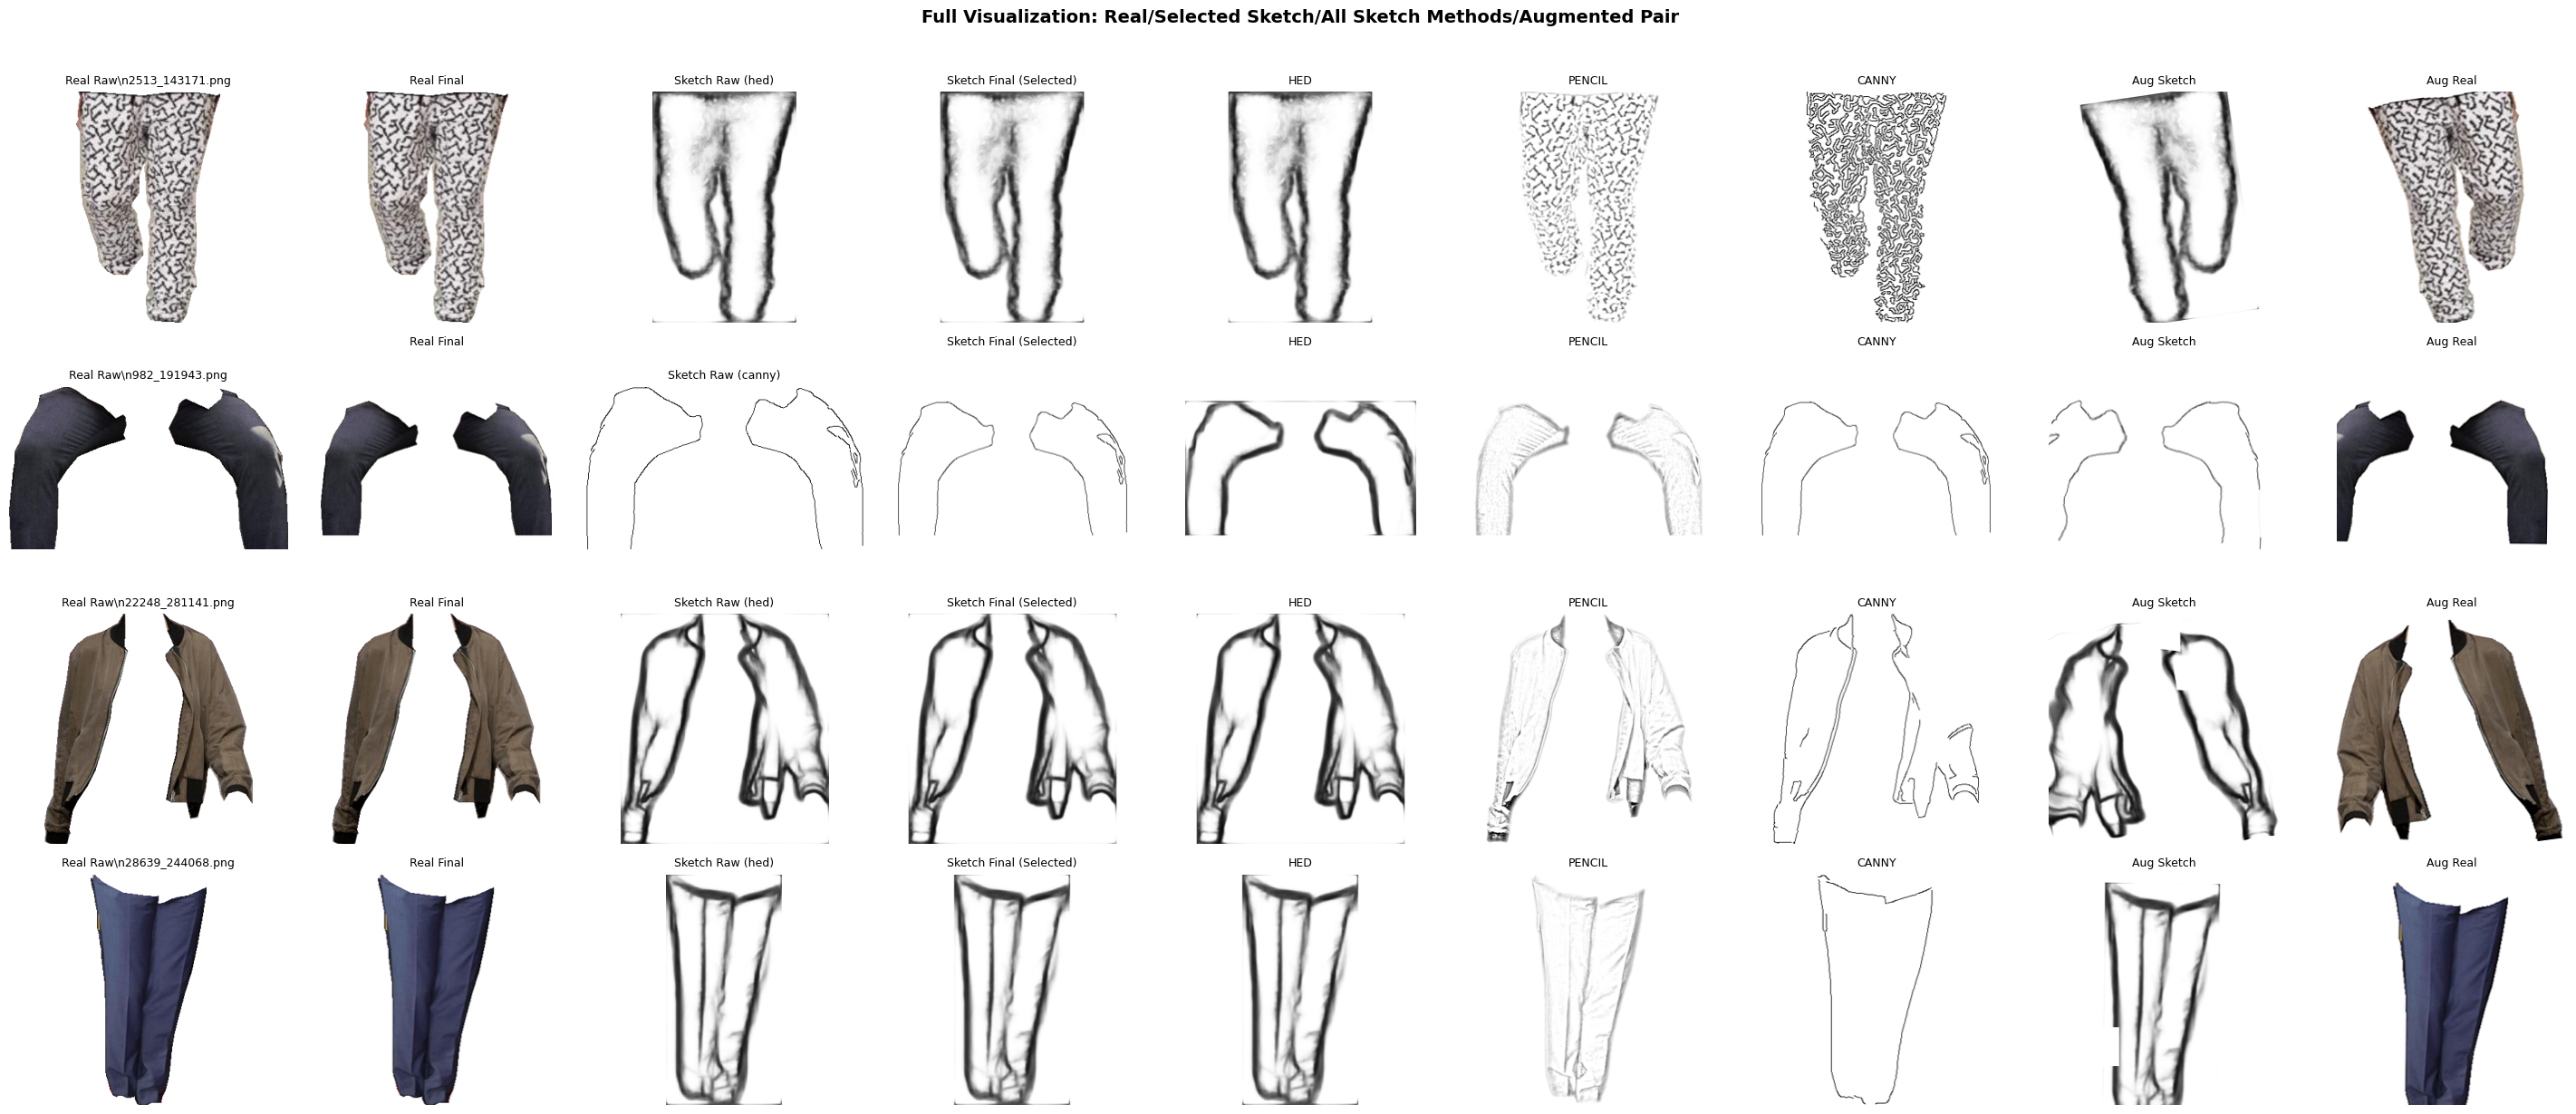

In [12]:
import matplotlib.pyplot as plt
import random
from pathlib import Path


def preprocess_preview(path: str, target_size: int = 256):
    """Return raw, smart-padded, and resized versions of one image."""
    with Image.open(path) as src_img:
        raw = src_img.convert("RGB")

    w, h = raw.size
    canvas_side = max(w, h, target_size)
    pad_left = (canvas_side - w) // 2
    pad_top = (canvas_side - h) // 2
    pad_right = canvas_side - w - pad_left
    pad_bottom = canvas_side - h - pad_top

    padded = ImageOps.expand(
        raw,
        border=(pad_left, pad_top, pad_right, pad_bottom),
        fill=(255, 255, 255),
    )
    resized = padded.resize((target_size, target_size), Image.BICUBIC)
    return raw, padded, resized


def find_sketch_by_method(row: dict, method: str):
    """Find sketch image path for a specific method using pipeline config roots."""
    if "PIPE_CFG" not in globals():
        return None

    root = PIPE_CFG.sketch_roots.get(method)
    if root is None:
        return None

    category = row["category"]
    stem = row["filename_stem"]
    method_dir = Path(root) / category
    if not method_dir.exists():
        return None

    for ext in IMG_EXTENSIONS:
        candidate = method_dir / f"{stem}{ext}"
        if candidate.exists():
            return str(candidate)
    return None


def tensor_to_uint8_img(t: torch.Tensor) -> np.ndarray:
    """Convert CHW tensor in [-1, 1] to HWC uint8 image."""
    arr = t.detach().cpu().permute(1, 2, 0).numpy()
    arr = ((arr + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    return arr


def visualize_full_samples(num_samples: int = 3, image_size: int = 256):
    """Visualize full sample information, including all sketch methods and augment result."""
    if "gan_rows" not in globals() or len(gan_rows) == 0:
        print("'gan_rows' chưa có dữ liệu. Hãy chạy Cell 15 trước.")
        return

    if "SketchToRealGANDataset" not in globals():
        print("Dataset class chưa sẵn sàng. Hãy chạy Cell 13 trước.")
        return

    sample_rows = random.sample(gan_rows, k=min(num_samples, len(gan_rows)))

    # Methods come from current config to guarantee complete per-method view.
    method_list = list(PIPE_CFG.sketch_roots.keys()) if "PIPE_CFG" in globals() else []

    # Build one augmented dataset instance to preview synchronized spatial augmentation.
    preview_dataset = SketchToRealGANDataset(
        rows=sample_rows,
        image_size=image_size,
        apply_augmentation=True,
    )

    # Columns: Real(raw/final), Selected Sketch(raw/final), each method final, augmented pair.
    n_cols = 4 + len(method_list) + 2
    fig, axes = plt.subplots(len(sample_rows), n_cols, figsize=(3.2 * n_cols, 3.0 * len(sample_rows)))
    if len(sample_rows) == 1:
        axes = [axes]

    print(f"Hiển thị {len(sample_rows)} mẫu | số cột: {n_cols}")

    for r, row in enumerate(sample_rows):
        # Real + selected sketch processing previews.
        real_raw, _, real_final = preprocess_preview(row["real_path"], target_size=image_size)
        sketch_raw, _, sketch_final = preprocess_preview(row["sketch_path"], target_size=image_size)

        # Augmented aligned pair preview.
        aug_item = preview_dataset[r]
        aug_sketch = tensor_to_uint8_img(aug_item["sketch"])
        aug_real = tensor_to_uint8_img(aug_item["real"])

        panels = [
            (real_raw, f"Real Raw\\n{Path(row['real_path']).name}"),
            (real_final, "Real Final"),
            (sketch_raw, f"Sketch Raw ({row['sketch_method']})"),
            (sketch_final, "Sketch Final (Selected)"),
        ]

        # Add each sketch type (hed/pencil/canny/...) for full comparison.
        for method in method_list:
            m_path = find_sketch_by_method(row, method)
            if m_path is None:
                blank = np.full((image_size, image_size, 3), 255, dtype=np.uint8)
                panels.append((blank, f"{method.upper()} (missing)"))
            else:
                _, _, m_final = preprocess_preview(m_path, target_size=image_size)
                panels.append((m_final, f"{method.upper()}"))

        panels.append((aug_sketch, "Aug Sketch"))
        panels.append((aug_real, "Aug Real"))

        for c, (img, title) in enumerate(panels):
            axes[r][c].imshow(img)
            axes[r][c].set_title(title, fontsize=9)
            axes[r][c].axis("off")

        # Write sample-level text at the first panel for quick traceability.
        axes[r][0].set_ylabel(
            f"Sample {r + 1}\\ncat: {row['category']}",
            rotation=90,
            fontsize=9,
            labelpad=10,
        )

    plt.suptitle(
        "Full Visualization: Real/Selected Sketch/All Sketch Methods/Augmented Pair",
        y=1.02,
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


# Run visualization
visualize_full_samples(num_samples=4, image_size=256)

# Mobile Sketch2Image (MS2I) Network Implementation

## Common Blocks

In [13]:
class UpSample(nn.Module):
    """ UpSampling block using PixelShuffle """
    def __init__(self, filters=64):
        super().__init__()
        self.conv = nn.Conv2d(filters, filters * 2, kernel_size=1, stride=1, padding=0, bias=True)
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor=2)

    def forward(self, x):
        x = self.conv(x)
        x = self.pixel_shuffle(x)
        return x

## DownSampling block
class DownSample(nn.Module):
    """ DownSampling block using PixelUnshuffle """
    def __init__(self, filters=64):
        super().__init__()
        self.conv = nn.Conv2d(filters, filters // 2, kernel_size=1, stride=1, padding=0, bias=True)
        self.pixel_unshuffle = nn.PixelUnshuffle(downscale_factor=2)

    def forward(self, x):
        """ SHAPE (B, C, H, W) -> SHAPE (B, C/4, H/2, W/2) """
        x = self.conv(x)
        x = self.pixel_unshuffle(x)
        return x

class ConvDown(nn.Module):
    """ DownSampling block using strided convolution """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1, bias=True)

    def forward(self, x):
        x = self.conv(x)
        return x

class ConvUp(nn.Module):
    """ UpSampling block using Upsample + convolution """
    def __init__(self, in_channels, out_channels, out_shape=None, scale_factor=None):
        super().__init__()
        assert (out_shape is not None) ^ (scale_factor is not None), "Either out_shape or scale_factor must be provided, but not both."
        if out_shape:
            self.out_shape = out_shape
            self.upsample = nn.Upsample(out_shape, mode='bilinear', align_corners=False)
        else:
            self.upsample = nn.Upsample(scale_factor=scale_factor, mode='bilinear', align_corners=False)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=True)

    def forward(self, x):
        x = self.upsample(x)
        x = self.conv(x)
        return x

def shape_estimation(h, w, kernel_size=3, stride=1, padding=1):
    """ Estimate the output shape after a convolutional layer. """
    out_h = (h + 2*padding - kernel_size) // stride + 1
    out_w = (w + 2*padding - kernel_size) // stride + 1
    return out_h, out_w

In [14]:
# Basic blocks
class DConvBlock(nn.Module):
    """ Custom Depthwise Convolution Block """
    def __init__(self, inshape, dim=64, expansion_factor=1.0, bias=False):
        super().__init__()
        hidden_features = int(dim*expansion_factor)
        self.conv = nn.Conv2d(inshape, hidden_features, kernel_size=1, bias=bias)
        self.depthwise = nn.Conv2d(hidden_features, hidden_features, kernel_size=3, stride=1, padding=1, groups=hidden_features, bias=bias)

    def forward(self, x):
        x = self.conv(x)
        x = self.depthwise(x)
        return x

# Custom LayerNormalization
class BiasFree_LayerNorm(nn.Module):
    """ Bias-Free Layer Normalization """
    def __init__(self, normalized_shape):
        super().__init__()
        if isinstance(normalized_shape, numbers.Integral):
            normalized_shape = (normalized_shape,)
        normalized_shape = torch.Size(normalized_shape)

        assert len(normalized_shape) == 1

        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.normalized_shape = normalized_shape

    def forward(self, x):
        x = x.contiguous() 
        sigma = x.var(-1, keepdim=True, unbiased=False)
        return x / torch.sqrt(sigma+1e-5) * self.weight

class WithBias_LayerNorm(nn.Module):
    """ With-Bias Layer Normalization """
    def __init__(self, normalized_shape):
        super().__init__()
        if isinstance(normalized_shape, numbers.Integral):
            normalized_shape = (normalized_shape,)
        normalized_shape = torch.Size(normalized_shape)

        assert len(normalized_shape) == 1

        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.normalized_shape = normalized_shape

    def forward(self, x):
        x = x.contiguous() 
        mu = x.mean(-1, keepdim=True)
        sigma = x.var(-1, keepdim=True, unbiased=False)
        return (x - mu) / torch.sqrt(sigma+1e-5) * self.weight + self.bias
    
class LayerNorm(nn.Module):
    """ Layer Normalization supporting two types: BiasFree and WithBias """
    def __init__(self, dim, LayerNorm_type, out_4d=True):
        super().__init__()
        if LayerNorm_type =='BiasFree':
            self.body = BiasFree_LayerNorm(dim)
        else:
            self.body = WithBias_LayerNorm(dim)
        self.out_4d = out_4d

    def to_3d(self, x):
        # Convert (B, C, H, W) to (B, H*W, C)
        if len(x.shape) == 3:
            return x
        elif len(x.shape) == 4:
            return rearrange(x, 'b c h w -> b (h w) c')
        else:
            raise ValueError("Input must be a 3D or 4D tensor")
    
    def to_4d(self, x, h, w):
        # Convert (B, H*W, C) to (B, C, H, W)
        if len(x.shape) == 4:
            return x
        elif len(x.shape) == 3:
            return rearrange(x, 'b (h w) c -> b c h w', h=h, w=w)
        else:
            raise ValueError("Input must be a 3D or 4D tensor")

    def forward(self, x):
        if self.out_4d:
            h, w = x.shape[-2:]
            return self.to_4d(self.body(self.to_3d(x)), h, w)
        else:
            return self.body(x)

## Reparameterization Block (RepBlock)

In [15]:
class RepConv3(nn.Module):
    def __init__(self, in_channels, out_channels, groups, deploy=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.groups = groups
        self.deploy = deploy
        self.reparam = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, groups=groups)
        if not deploy:
            self.conv_3x3 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, groups=groups)
            self.conv_1x1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, groups=groups)
            self.conv_1x3 = nn.Conv2d(in_channels, out_channels, kernel_size=(1, 3), padding=(0, 1), groups=groups)
            self.conv_3x1 = nn.Conv2d(in_channels, out_channels, kernel_size=(3, 1), padding=(1, 0), groups=groups)
            self.conv_1x1_branch = nn.Conv2d(in_channels, in_channels, kernel_size=1, groups=groups, bias=False)
            self.conv_3x3_branch = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, groups=groups, bias=False)
        else:
            self._delete_branches()

    def _delete_branches(self):
        for name in ['conv_3x3','conv_1x1','conv_1x3','conv_3x1', 'conv_1x1_branch', 'conv_3x3_branch']:
            if hasattr(self, name):
                delattr(self, name)

    def fuse(self, delete_branches=True):
        if self.deploy:
            return
        # Extract weights and biases
        conv_3x3_w, conv_3x3_b = self.conv_3x3.weight, self.conv_3x3.bias
        conv_1x1_w, conv_1x1_b = self.conv_1x1.weight, self.conv_1x1.bias
        conv_1x3_w, conv_1x3_b = self.conv_1x3.weight, self.conv_1x3.bias
        conv_3x1_w, conv_3x1_b = self.conv_3x1.weight, self.conv_3x1.bias
        conv_1x1_branch_w, conv_3x3_branch_w = self.conv_1x1_branch.weight, self.conv_3x3_branch.weight
        # Pad the smaller kernels to 3x3
        conv_1x1_w_pad = F.pad(conv_1x1_w, [1, 1, 1, 1])
        conv_1x3_w_pad = F.pad(conv_1x3_w, [0, 0, 1, 1])
        conv_3x1_w_pad = F.pad(conv_3x1_w, [1, 1, 0, 0])
        if self.groups == 1:
            conv_1x1_3x3_w_pad = F.conv2d(conv_3x3_branch_w, conv_1x1_branch_w.permute(1, 0, 2, 3))
        else:
            w_slices = []
            conv_1x1_branch_w_T = conv_1x1_branch_w.permute(1, 0, 2, 3)
            in_channels_per_group = self.in_channels // self.groups
            out_channels_per_group = self.out_channels // self.groups
            for g in range(self.groups):
                # Slice the transposed 1x1 weights for this group's channels
                conv_1x1_branch_w_T_slice = conv_1x1_branch_w_T[:, g*in_channels_per_group:(g+1)*in_channels_per_group, :, :]
                # Slice the 3x3 weights for this group's output channels
                conv_3x3_branch_w_slice = conv_3x3_branch_w[g*out_channels_per_group:(g+1)*out_channels_per_group, :, :, :]
                w_slices.append(F.conv2d(conv_3x3_branch_w_slice, conv_1x1_branch_w_T_slice))
            conv_1x1_3x3_w_pad = torch.cat(w_slices, dim=0)
        # Fuse weights and biases
        conv_w = conv_3x3_w + conv_1x1_w_pad + conv_1x3_w_pad + conv_3x1_w_pad + conv_1x1_3x3_w_pad
        if conv_3x3_b is None:
            conv_3x3_b = torch.zeros(self.out_channels, device=conv_w.device)
        conv_b = conv_3x3_b + conv_1x1_b + conv_1x3_b + conv_3x1_b
        self.reparam.weight.data.copy_(conv_w)
        self.reparam.bias.data.copy_(conv_b)
        # Delete the original branches
        if delete_branches:
            self._delete_branches()
        # Set deploy flag
        self.deploy = True

    def forward(self, x):
        if self.deploy:
            return self.reparam(x)
        else:
            return self.conv_3x3(x) + self.conv_1x1(x) + self.conv_1x3(x) + self.conv_3x1(x) + self.conv_3x3_branch(self.conv_1x1_branch(x))

# # Test repconv
# conv = RepConv3(16, 32, groups=16, deploy=False)
# x = torch.randn(1, 16, 64, 64)
# out1 = conv(x)
# print(f"Before fusion: {count_params(conv)} parameters")
# conv.fuse()
# out2 = conv(x)
# print(f"After fusion: {count_params(conv)} parameters")
# print(torch.allclose(out1, out2, atol=1e-5))

In [16]:
class RepConv5(nn.Module):
    def __init__(self, in_channels, out_channels, groups=1, deploy=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.groups = groups
        self.deploy = deploy
        self.reparam = nn.Conv2d(in_channels, out_channels, 5, padding=2, groups=groups)

        if not deploy:
            # Main branches
            self.conv_5x5 = nn.Conv2d(in_channels, out_channels, 5, padding=2, groups=groups)
            self.conv_3x3 = nn.Conv2d(in_channels, out_channels, 3, padding=1, groups=groups)
            self.conv_1x1 = nn.Conv2d(in_channels, out_channels, 1, groups=groups)
            # Asymmetric branches
            self.conv_1x5 = nn.Conv2d(in_channels, out_channels, (1,5), padding=(0,2), groups=groups)
            self.conv_5x1 = nn.Conv2d(in_channels, out_channels, (5,1), padding=(2,0), groups=groups)
            self.conv_1x3 = nn.Conv2d(in_channels, out_channels, (1,3), padding=(0,1), groups=groups)
            self.conv_3x1 = nn.Conv2d(in_channels, out_channels, (3,1), padding=(1,0), groups=groups)
            self.conv_3x5 = nn.Conv2d(in_channels, out_channels, (3,5), padding=(1,2), groups=groups)
            self.conv_5x3 = nn.Conv2d(in_channels, out_channels, (5,3), padding=(2,1), groups=groups)
            # Sequential branch
            self.conv_1x1_branch = nn.Conv2d(in_channels, in_channels, 1, groups=groups, bias=False)
            self.conv_5x5_branch = nn.Conv2d(in_channels, out_channels, 5, padding=2, groups=groups, bias=False)
        else:
            self._delete_branches()

    def _delete_branches(self):
        for name in [
            'conv_5x5','conv_3x3','conv_1x1',
            'conv_1x5','conv_5x1',
            'conv_1x3','conv_3x1',
            'conv_3x5','conv_5x3',
            'conv_1x1_branch','conv_5x5_branch'
        ]:
            if hasattr(self, name):
                delattr(self, name)

    def _pad_to_5x5(self, w):
        _, _, h, w_k = w.shape
        pad_h = 5 - h
        pad_w = 5 - w_k
        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left
        return F.pad(w, [pad_left, pad_right, pad_top, pad_bottom])

    def fuse(self, delete_branches=True):
        if self.deploy:
            return
        def get_wb(conv):
            return conv.weight, conv.bias if conv.bias is not None else torch.zeros(self.out_channels, device=conv.weight.device)
        W = 0
        B = 0
        # Helper to accumulate
        def add_branch(w, b):
            nonlocal W, B
            W = W + w
            B = B + b
        # Main kernels
        w, b = get_wb(self.conv_5x5)
        add_branch(w, b)
        w, b = get_wb(self.conv_3x3)
        add_branch(self._pad_to_5x5(w), b)
        w, b = get_wb(self.conv_1x1)
        add_branch(self._pad_to_5x5(w), b)
        # Asymmetric
        w, b = get_wb(self.conv_1x5)
        add_branch(self._pad_to_5x5(w), b)
        w, b = get_wb(self.conv_5x1)
        add_branch(self._pad_to_5x5(w), b)
        w, b = get_wb(self.conv_1x3)
        add_branch(self._pad_to_5x5(w), b)
        w, b = get_wb(self.conv_3x1)
        add_branch(self._pad_to_5x5(w), b)
        w, b = get_wb(self.conv_3x5)
        add_branch(self._pad_to_5x5(w), b)
        w, b = get_wb(self.conv_5x3)
        add_branch(self._pad_to_5x5(w), b)
        # Sequential 1x1 -> 5x5
        w1 = self.conv_1x1_branch.weight
        w2 = self.conv_5x5_branch.weight
        if self.groups == 1:
            w_seq = F.conv2d(w2, w1.permute(1,0,2,3))
        else:
            w_slices = []
            w1_T = w1.permute(1,0,2,3)
            icpg = self.in_channels // self.groups
            ocpg = self.out_channels // self.groups
            for g in range(self.groups):
                w1_slice = w1_T[:, g*icpg:(g+1)*icpg]
                w2_slice = w2[g*ocpg:(g+1)*ocpg]
                w_slices.append(F.conv2d(w2_slice, w1_slice))
            w_seq = torch.cat(w_slices, dim=0)
        add_branch(w_seq, torch.zeros(self.out_channels, device=w_seq.device))
        self.reparam.weight.data.copy_(W)
        self.reparam.bias.data.copy_(B)
        if delete_branches:
            self._delete_branches()
        self.deploy = True

    def forward(self, x):
        if self.deploy:
            return self.reparam(x)
        return (
            self.conv_5x5(x)
            + self.conv_3x3(x)
            + self.conv_1x1(x)
            + self.conv_1x5(x)
            + self.conv_5x1(x)
            + self.conv_1x3(x)
            + self.conv_3x1(x)
            + self.conv_3x5(x)
            + self.conv_5x3(x)
            + self.conv_5x5_branch(self.conv_1x1_branch(x))
        )

# # Test RepConv5
# conv = RepConv5(16, 32, groups=16, deploy=False)
# x = torch.randn(1, 16, 64, 64)
# out1 = conv(x)
# print(f"Before fusion: {count_params(conv)} parameters")
# conv.fuse()
# out2 = conv(x)
# print(f"After fusion: {count_params(conv)} parameters")
# print(torch.allclose(out1, out2, atol=1e-5))

In [17]:
class RepConv7(nn.Module):
    def __init__(self, in_channels, out_channels, groups=1, deploy=False):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.groups = groups
        self.deploy = deploy

        self.reparam = nn.Conv2d(in_channels, out_channels, 7, padding=3, groups=groups)

        if not deploy:
            # Main
            self.conv_7x7 = nn.Conv2d(in_channels, out_channels, 7, padding=3, groups=groups)
            # Directional
            self.conv_7x1 = nn.Conv2d(in_channels, out_channels, (7,1), padding=(3,0), groups=groups)
            self.conv_1x7 = nn.Conv2d(in_channels, out_channels, (1,7), padding=(0,3), groups=groups)
            # Mixed large
            self.conv_7x5 = nn.Conv2d(in_channels, out_channels, (7,5), padding=(3,2), groups=groups)
            self.conv_5x7 = nn.Conv2d(in_channels, out_channels, (5,7), padding=(2,3), groups=groups)
            # Mid
            self.conv_5x5 = nn.Conv2d(in_channels, out_channels, 5, padding=2, groups=groups)
            # Small directional
            self.conv_1x5 = nn.Conv2d(in_channels, out_channels, (1,5), padding=(0,2), groups=groups)
            self.conv_5x1 = nn.Conv2d(in_channels, out_channels, (5,1), padding=(2,0), groups=groups)
            # Sequential branch
            self.conv_1x1_branch = nn.Conv2d(in_channels, in_channels, 1, groups=groups, bias=False)
            self.conv_7x7_branch = nn.Conv2d(in_channels, out_channels, 7, padding=3, groups=groups, bias=False)
        else:
            self._delete_branches()

    def _delete_branches(self):
        for name in [
            'conv_7x7',
            'conv_7x1','conv_1x7',
            'conv_7x5','conv_5x7',
            'conv_5x5',
            'conv_1x5','conv_5x1',
            'conv_1x1_branch','conv_7x7_branch'
        ]:
            if hasattr(self, name):
                delattr(self, name)

    def _pad_to_7x7(self, w):
        _, _, h, w_k = w.shape
        pad_h = 7 - h
        pad_w = 7 - w_k
        pad_top = pad_h // 2
        pad_bottom = pad_h - pad_top
        pad_left = pad_w // 2
        pad_right = pad_w - pad_left
        return F.pad(w, [pad_left, pad_right, pad_top, pad_bottom])

    def fuse(self, delete_branches=True):
        if self.deploy:
            return
        def get_wb(conv):
            return conv.weight, conv.bias if conv.bias is not None else torch.zeros(self.out_channels, device=conv.weight.device)
        W = torch.zeros_like(self.reparam.weight)
        B = torch.zeros_like(self.reparam.bias)
        def add_branch(w, b):
            nonlocal W, B
            W += w
            B += b
        # Main
        w, b = get_wb(self.conv_7x7)
        add_branch(w, b)
        # Directional
        for conv in [self.conv_7x1, self.conv_1x7]:
            w, b = get_wb(conv)
            add_branch(self._pad_to_7x7(w), b)
        # Mixed large
        for conv in [self.conv_7x5, self.conv_5x7]:
            w, b = get_wb(conv)
            add_branch(self._pad_to_7x7(w), b)
        # Mid
        w, b = get_wb(self.conv_5x5)
        add_branch(self._pad_to_7x7(w), b)
        # Small directional
        for conv in [self.conv_1x5, self.conv_5x1]:
            w, b = get_wb(conv)
            add_branch(self._pad_to_7x7(w), b)
        # Sequential 1x1 → 7x7
        w1 = self.conv_1x1_branch.weight
        w2 = self.conv_7x7_branch.weight
        if self.groups == 1:
            w_seq = F.conv2d(w2, w1.permute(1,0,2,3))
        else:
            w_slices = []
            w1_T = w1.permute(1,0,2,3)
            icpg = self.in_channels // self.groups
            ocpg = self.out_channels // self.groups
            for g in range(self.groups):
                w1_slice = w1_T[:, g*icpg:(g+1)*icpg]
                w2_slice = w2[g*ocpg:(g+1)*ocpg]
                w_slices.append(F.conv2d(w2_slice, w1_slice))
            w_seq = torch.cat(w_slices, dim=0)
        add_branch(w_seq, torch.zeros(self.out_channels, device=w_seq.device))
        self.reparam.weight.data.copy_(W)
        self.reparam.bias.data.copy_(B)
        if delete_branches:
            self._delete_branches()
        self.deploy = True

    def forward(self, x):
        if self.deploy:
            return self.reparam(x)
        return (
            self.conv_7x7(x)
            + self.conv_7x1(x)
            + self.conv_1x7(x)
            + self.conv_7x5(x)
            + self.conv_5x7(x)
            + self.conv_5x5(x)
            + self.conv_1x5(x)
            + self.conv_5x1(x)
            + self.conv_7x7_branch(self.conv_1x1_branch(x))
        )

# # Test RepConv7
# conv = RepConv7(16, 32, groups=16, deploy=False)
# x = torch.randn(1, 16, 64, 64)
# out1 = conv(x)
# print(f"Before fusion: {count_params(conv)} parameters")
# conv.fuse()
# out2 = conv(x)
# print(f"After fusion: {count_params(conv)} parameters")
# print(torch.allclose(out1, out2, atol=1e-5))

## Attention Block (MonarchAttn)

In [18]:
# Thêm đường dẫn tới folder monarch-attention vào hệ thống
sys.path.append(os.path.abspath('monarch-attention'))

from ma.monarch_attention import MonarchAttention
@dataclass
class RepAttnConfig:
    dim: int
    num_heads: int = 8
    block_size: int = 16
    num_steps: int = 2
    pad_type: str = "pre"
    impl: str = "torch"
    deploy: bool = False

class RepAttn(nn.Module):
    """ Re-parameterizable Attention Block using MonarchAttention as the core attention mechanism."""
    def __init__(self, dim, num_heads=8, block_size=14, num_steps=1, pad_type="pre", impl="torch", deploy=False):
        super().__init__()
        self.num_heads = num_heads
        self.qkv = nn.Conv2d(dim, dim * 3, kernel_size=1)
        self.monarch_attn = MonarchAttention(
            block_size=block_size,
            num_steps=num_steps,
            pad_type=pad_type,
            impl=impl
        )
        if deploy:
            self.attn_fn = self.monarch_attn
        else:
            self.attn_fn = self.common_attn
        self.proj = nn.Conv2d(dim, dim, kernel_size=1)
        self.deploy = deploy

    def common_attn(self, q, k, v):
        """ Scaled Dot-Product Attention """
        scale = (q.shape[-1]) ** -0.5
        attn = (q @ k.transpose(-2, -1)) * scale
        attn = attn.softmax(dim=-1)
        out = attn @ v
        return out

    @torch.no_grad()
    def fuse(self):
        if not self.deploy:
            self.attn_fn = self.monarch_attn
            self.deploy = True

    def forward(self, x):
        B, C, H, W = x.shape
        qkv = self.qkv(x)
        q, k, v = torch.chunk(qkv, 3, dim=1)
        q = rearrange(q, 'b (head c) h w -> b head c (h w)', head=self.num_heads)
        k = rearrange(k, 'b (head c) h w -> b head c (h w)', head=self.num_heads)
        v = rearrange(v, 'b (head c) h w -> b head c (h w)', head=self.num_heads)
        attn_out = self.attn_fn(q, k, v)
        attn_out = rearrange(attn_out, 'b head c (h w) -> b (head c) h w', head=self.num_heads, h=H, w=W)
        out = self.proj(attn_out)
        return out

# # Test RepAttn
# attn = RepAttn(dim=256, num_heads=8, block_size=14, num_steps=1, pad_type="pre", impl="torch", deploy=False).cuda()
# x = torch.randn(1, 256, 45, 31).cuda()
# out = attn(x)
# print(out.shape)

## Simple ConvFFN

In [19]:
@dataclass
class FFNConfig:
    dim: int
    expansion_factor: int = 1
    deploy: bool = False

In [20]:
class RepFFN(nn.Module):
    def __init__(self, dim, expansion_factor=1, deploy=False):
        super().__init__()
        hidden_features = int(dim * expansion_factor)
        self.project_in = RepConv3(dim, hidden_features, groups=1, deploy=deploy)
        self.dwconv = RepConv3(hidden_features, hidden_features*2, groups=hidden_features, deploy=deploy)
        self.project_out = nn.Conv2d(hidden_features, dim, kernel_size=1)

    @torch.no_grad()
    def fuse(self):
        self.project_in.fuse()
        self.dwconv.fuse()  


    def forward(self, x):
        x = self.project_in(x)
        x1, x2 = self.dwconv(x).chunk(2, dim=1)
        x = F.gelu(x1) * x2
        x = self.project_out(x)
        return x

## Model Blocks

In [21]:
class SkipConnection(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.conv = nn.Conv2d(dim*2, dim, kernel_size=1)

    def forward(self, x1, x2):
        x = torch.cat([x1, x2], dim=1)
        x = self.conv(x)
        return x
    
class RepTransformerBlock(nn.Module):
    def __init__(self, rep_attn_cfg: RepAttnConfig, ffn_cfg: FFNConfig, norm_type='WithBias'):
        super().__init__()
        self.rep_attn = RepAttn(**asdict(rep_attn_cfg))
        self.rep_ffn = RepFFN(**asdict(ffn_cfg))
        self.norm1 = LayerNorm(rep_attn_cfg.dim, norm_type)
        self.norm2 = LayerNorm(rep_attn_cfg.dim, norm_type)

    @torch.no_grad()
    def fuse(self):
        self.rep_attn.fuse()
        self.rep_ffn.fuse()

    def forward(self, x):
        x = x + self.rep_attn(self.norm1(x))
        x = x + self.rep_ffn(self.norm2(x))
        return x
    
class Block(nn.Module):
    def __init__(self, num_block, rep_attn_cfg: RepAttnConfig, ffn_cfg: FFNConfig, norm_type='WithBias'):
        super().__init__()
        self.num_block = num_block
        self.blocks = nn.ModuleList([
            RepTransformerBlock(rep_attn_cfg, ffn_cfg, norm_type) for _ in range(num_block)
        ])

    @torch.no_grad()
    def fuse(self):
        for block in self.blocks:
            block.fuse()

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x

In [22]:
class Head(nn.Module):
    def __init__(self, in_channels, out_channels=3, deploy=False, last_act=None):
        super().__init__()
        hidden = max(in_channels // 2, 8)
        self.pre = RepConv3(in_channels, hidden, 1, deploy=deploy)
        self.to_rgb = nn.Conv2d(hidden, out_channels, kernel_size=1)
        self.last_act = last_act if last_act is not None else nn.Identity()

    @torch.no_grad()
    def fuse(self):
        if isinstance(self.pre, RepConv3):
            self.pre.fuse()

    def forward(self, x):
        x = F.gelu(self.pre(x))
        return self.last_act(self.to_rgb(x))

class MS2I(nn.Module):
    """Structure-based disentangled MS2I generator."""

    def __init__(
        self,
        input_shape=(3, 256, 256),
        deploy=False,
        dims=[48, 96, 192, 384],
        num_blocks=[4, 6, 6, 8],
        num_heads=[1, 2, 2, 4],
        bias=True,
        last_act=None,
    ):
        super().__init__()
        assert len(dims) == len(num_blocks) == len(num_heads), "Length of dims, num_blocks and num_heads must be the same"
        self.input_shape = input_shape
        self.deploy = deploy
        self.dims = dims
        self.num_blocks = num_blocks
        self.bias = bias
        self.num_heads = num_heads

        # Structure encoder: sketch is the only input here, so early features stay layout-dominant.
        self.stem = nn.Conv2d(3, dims[0], kernel_size=7, stride=4, padding=3, bias=bias)

        layers = []
        down_convs = []
        for idx in range(len(dims)):
            attn_cfg, ffn_cfg = self.build_cfg(dims[idx], num_heads[idx])
            block = Block(num_blocks[idx], attn_cfg, ffn_cfg, norm_type='WithBias')
            if idx < len(dims) - 1:
                down_convs.append(DownSample(dims[idx]))
            layers.append(block)
        self.bottleneck = layers[-1]
        self.encoder = nn.ModuleList(layers[:-1])
        self.downsample = nn.ModuleList(down_convs)

        layers = []
        up_convs = []
        skip_connections = []
        for stage, idx in enumerate(range(len(dims) - 2, -1, -1)):
            attn_cfg, ffn_cfg = self.build_cfg(dims[idx], num_heads[idx])
            up_convs.append(UpSample(dims[idx + 1]))
            skip_connections.append(SkipConnection(dims[idx]))
            layers.append(Block(num_blocks[idx], attn_cfg, ffn_cfg, norm_type='WithBias'))
        self.decoder = nn.ModuleList(layers)
        self.up_sample = nn.ModuleList(up_convs)
        self.skip = nn.ModuleList(skip_connections)

        self.head = Head(dims[0], out_channels=3, deploy=deploy, last_act=last_act)

    @torch.no_grad()
    def fuse(self):
        for block in self.encoder:
            block.fuse()
        self.bottleneck.fuse()
        for block in self.decoder:
            block.fuse()
        self.head.fuse()

    def build_cfg(self, dim, head):
        attn_cfg = RepAttnConfig(
            dim=dim,
            num_heads=head,
            block_size=16,
            num_steps=2,
            pad_type="pre",
            impl="torch",
            deploy=self.deploy,
        )
        ffn_cfg = FFNConfig(dim=dim, expansion_factor=1)
        return attn_cfg, ffn_cfg

    def forward(self, sketch, return_latents=False):

        x = self.stem(sketch)
        structure_feats = []
        for blk, down in zip(self.encoder, self.downsample):
            x = blk(x)
            structure_feats.append(x)
            x = down(x)

        x = self.bottleneck(x)

        for blk, up, skip in zip(self.decoder, self.up_sample, self.skip):
            x = up(x)
            cur_feat = structure_feats.pop()
            x = skip(x, cur_feat)
            x = blk(x)

        x = F.interpolate(x, size=self.input_shape[1:], mode='bilinear', align_corners=False)
        out = self.head(x)
        if return_latents:
            return out, {'structure': x}
        return out

In [23]:
model_cfg = {
    'input_shape': (3, 256, 256),
    'dims': [32, 64, 128, 256],
    'num_blocks': [1, 2, 2, 4],
    'num_heads': [1, 2, 4, 8],
    'bias': True,
    'last_act': None,
    'deploy': False,
}

# Test the model with sketch inputs.
model = MS2I(**model_cfg).to(DEVICE)
sketch = torch.randn(1, 3, 256, 256, device=DEVICE)
y, latents = model(sketch, return_latents=True)
print(f"Output shape: {y.shape}")
print(f"Structure feature shape: {latents['structure'].shape}")


Output shape: torch.Size([1, 3, 256, 256])
Structure feature shape: torch.Size([1, 32, 256, 256])


In [24]:

# from fvcore.nn import FlopCountAnalysis, flop_count_table

# print("MS2I Model Parameter Count:")
# total, trainable = count_params(model)
# print(f"Total: {total:,} | Trainable: {trainable:,}")
# print("#" * 50)
# print("MS2I Model FLOPs:")
# sketch = torch.randn(1, 3, 256, 256, device=DEVICE)
#
#
# flops = FlopCountAnalysis(model, (sketch,))
# print(f"Total FLOPs: {flops.total():,.2f}")
# print("#" * 50)
# print("Detailed Parameter Count:")
# print(flop_count_table(flops))


In [25]:
# Fuse model
model.fuse()
sketch = torch.randn(1, 3, 256, 256, device=DEVICE)
y = model(sketch)
print(f"Output shape after fusion: {y.shape}")


Output shape after fusion: torch.Size([1, 3, 256, 256])


In [26]:

# from fvcore.nn import FlopCountAnalysis, flop_count_table

# print("MS2I Model Parameter Count (After fusion):")
# total, trainable = count_params(model)
# print(f"Total: {total:,} | Trainable: {trainable:,}")
# print("#" * 50)
# print("MS2I Model FLOPs (After fusion):")
# sketch = torch.randn(1, 3, 256, 256, device=DEVICE)
#
#
# flops = FlopCountAnalysis(model, (sketch,))
# print(f"Total FLOPs (After fusion): {flops.total():,.2f}")
# print("#" * 50)
# print("Detailed Parameter Count (After fusion):")
# print(flop_count_table(flops))


In [27]:
import time

sketch = torch.randn(1, 3, 256, 256).to('cpu')
model = model.to('cpu')
# Warm-up
with torch.no_grad():
    for _ in range(10):
        _ = model(sketch)

# Timing
start_time = time.time()
with torch.no_grad():
    for _ in range(100):
        _ = model(sketch)
end_time = time.time()

avg_time = (end_time - start_time) / 100
print(f"Average inference time: {avg_time * 1000:.3f} ms")


Average inference time: 117.903 ms


# Simple Convolution Discriminator

In [28]:
from torch.nn.utils import spectral_norm

# Conv-BN-LeakyReLU block
class ConvBNLReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, padding=1, negative_slope=0.2, use_sn=True):
        super().__init__()
        conv = nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False)
        conv = spectral_norm(conv) if use_sn else conv
        self.block = nn.Sequential(
            conv,
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(negative_slope, inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# Residual Block
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, downsample=False, use_sn=True):
        super().__init__()

        stride = 2 if downsample else 1

        self.conv1 = ConvBNLReLU(in_ch, out_ch, stride=stride, use_sn=use_sn)
        conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        conv2 = spectral_norm(conv2) if use_sn else conv2
        self.conv2 = nn.Sequential(
            conv2,
            nn.BatchNorm2d(out_ch)
        )

        self.act = nn.LeakyReLU(0.2, inplace=True)

        # Skip connection
        if downsample or in_ch != out_ch:
            skip_conv = nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False)
            skip_conv = spectral_norm(skip_conv) if use_sn else skip_conv
            self.skip = nn.Sequential(
                skip_conv,
                nn.BatchNorm2d(out_ch)
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        identity = self.skip(x)

        out = self.conv1(x)
        out = self.conv2(out)

        out += identity
        out = self.act(out)
        return out

In [29]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=3, base_dim=64, use_sn=True):
        super().__init__()

        stem_conv = nn.Conv2d(in_channels, base_dim, kernel_size=4, stride=2, padding=1, bias=False)
        stem_conv = spectral_norm(stem_conv) if use_sn else stem_conv

        # Stem
        self.stem = nn.Sequential(
            stem_conv,
            nn.BatchNorm2d(base_dim),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Residual stages
        self.layer1 = ResBlock(base_dim, base_dim * 2, downsample=True, use_sn=use_sn)
        self.layer2 = ResBlock(base_dim * 2, base_dim * 4, downsample=True, use_sn=use_sn)
        self.layer3 = ResBlock(base_dim * 4, base_dim * 8, downsample=True, use_sn=use_sn)
        self.layer4 = ResBlock(base_dim * 8, base_dim * 8, downsample=False, use_sn=use_sn)

        # Patch output head
        head_conv = nn.Conv2d(base_dim * 8, 1, kernel_size=4, stride=1, padding=1)
        self.head = spectral_norm(head_conv) if use_sn else head_conv

    def forward(self, x):
        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.head(x)
        return x

In [30]:
discriminator = Discriminator().to(DEVICE)
x = torch.randn(1, 3, 256, 256).to(DEVICE)
out = discriminator(x)
print(f"Discriminator output shape: {out.shape}")

Discriminator output shape: torch.Size([1, 1, 15, 15])


In [31]:
# from fvcore.nn import FlopCountAnalysis, flop_count_table

# print("Discriminator Model Parameter Count:")
# total, trainable = count_params(discriminator)
# print(f"Total: {total:,} | Trainable: {trainable:,}")
# print("#" * 50)
# print("Discriminator Model FLOPs:")
# x = torch.randn(1, 3, 256, 256)
# flops = FlopCountAnalysis(discriminator, x.to(DEVICE))
# print(f"Total FLOPs: {flops.total():,.2f}")
# print("#" * 50)
# print("Detailed Parameter Count:")
# print(flop_count_table(flops))

# Training Script

In [32]:
# Compatibility patch for some Kaggle runtimes where torch._dynamo.disable
# does not accept the `wrapping` keyword used internally by torch optimizer setup.
import inspect
import torch.optim.optimizer as torch_optimizer_module

def patch_torch_dynamo_disable():
    if not hasattr(torch, "_dynamo") or not hasattr(torch._dynamo, "disable"):
        return False

    original_disable = torch._dynamo.disable
    try:
        sig = inspect.signature(original_disable)
    except Exception:
        return False

    if "wrapping" in sig.parameters:
        return False

    def disable_compat(fn=None, recursive=True, wrapping=None, *args, **kwargs):
        # Ignore unsupported args and forward only parameters accepted by old signature.
        if fn is None:
            try:
                return original_disable(recursive=recursive)
            except TypeError:
                return original_disable()
        try:
            return original_disable(fn=fn, recursive=recursive)
        except TypeError:
            return original_disable(fn)

    torch._dynamo.disable = disable_compat
    return True

def patch_optimizer_disable_wrapper():
    # If Optimizer.__init__ was already wrapped by a broken dynamo-disable decorator,
    # unwrap it to the original function.
    init_fn = torch_optimizer_module.Optimizer.__init__
    if hasattr(init_fn, "__wrapped__"):
        torch_optimizer_module.Optimizer.__init__ = init_fn.__wrapped__
        return True
    return False

patched_disable = patch_torch_dynamo_disable()
patched_optimizer = patch_optimizer_disable_wrapper()
print("Patched torch._dynamo.disable:", patched_disable)
print("Patched Optimizer.__init__ wrapper:", patched_optimizer)

Patched torch._dynamo.disable: False
Patched Optimizer.__init__ wrapper: False


## Training - Part 1: Imports & Configuration

In [33]:

import csv
import json
import time
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import defaultdict
from torch.amp import autocast, GradScaler
from torch.optim import Adam

torch.backends.cudnn.benchmark = True if DEVICE.type == 'cuda' else False

# Training configuration
@dataclass
class TrainConfig:
    val_ratio: float = 0.1
    batch_size: int = 8
    image_size: int = 256
    epochs: int = 50
    lr_g: float = 2e-4
    lr_d: float = 2e-4
    beta1: float = 0.5
    beta2: float = 0.999
    lambda_perc: float = 10.0
    lambda_l1: float = 100.0
    perceptual_layers: tuple = (3, 8, 17, 26, 35)
    perceptual_layer_weights: tuple = (1.0, 1.0, 1.0, 1.0, 1.0)
    sample_every: int = 1
    save_every: int = 1
    seed: int = 42
    use_amp: bool = True
    num_workers: int = 0 if os.name == 'nt' else 4
    grad_clip_g: float = 1.0
    grad_clip_d: float = 1.0
    d_label_smooth_real: float = 0.9
    d_label_smooth_fake: float = 0.0
    log_every_steps: int = 20
    resume_checkpoint: str = ''
    resume_strict: bool = True

WANDB_PROJECT = os.environ.get('WANDB_PROJECT', 'ms2i-net')
WANDB_MODE = 'online'


## Training - Part 2: VGG Feature Extractor & Perceptual Loss

In [34]:
def load_vgg19_features_safe():
    """Load VGG19 features with fallback for torchvision mismatch runtimes."""
    try:
        from torchvision.models import vgg19, VGG19_Weights
        model = vgg19(weights=VGG19_Weights.IMAGENET1K_V1)
        print('Loaded VGG19 from torchvision.models')
        return model.features.eval()
    except Exception as e:
        print(f'torchvision load failed: {e}')
        print('Trying torch.hub fallback (pytorch/vision:v0.10.0)...')
        try:
            model = torch.hub.load('pytorch/vision:v0.10.0', 'vgg19', pretrained=True)
            print('Loaded VGG19 from torch.hub fallback')
            return model.features.eval()
        except Exception as hub_e:
            raise RuntimeError(
                'Cannot load VGG19 for perceptual loss. '
                'Please install compatible torch/torchvision, or temporarily set lambda_perc=0.0. '
                f'torchvision_error={e}; hub_error={hub_e}'
            )

class VGGFeatureExtractor(nn.Module):
    """Extract intermediate VGG19 feature maps for perceptual loss."""
    def __init__(self, layer_ids=(3, 8, 17, 26, 35)):
        super().__init__()
        vgg_features = load_vgg19_features_safe()
        for p in vgg_features.parameters():
            p.requires_grad = False

        self.blocks = nn.ModuleList()
        start = 0
        for end in sorted(layer_ids):
            self.blocks.append(nn.Sequential(*[vgg_features[i] for i in range(start, end + 1)]))
            start = end + 1

        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        self.register_buffer('mean', mean)
        self.register_buffer('std', std)

    def _to_vgg_space(self, x):
        # Training tensors are in [-1, 1], VGG expects ImageNet-normalized [0, 1].
        x = (x.clamp(-1.0, 1.0) + 1.0) / 2.0
        return (x - self.mean) / self.std

    def forward(self, x):
        x = self._to_vgg_space(x)
        features = []
        for block in self.blocks:
            x = block(x)
            features.append(x)
        return features


class VGGPerceptualLoss(nn.Module):
    def __init__(self, layer_ids=(3, 8, 17, 26, 35), layer_weights=(1.0, 1.0, 1.0, 1.0, 1.0)):
        super().__init__()
        if len(layer_ids) != len(layer_weights):
            raise ValueError('perceptual_layers and perceptual_layer_weights must have the same length')
        self.layer_weights = [float(w) for w in layer_weights]
        self.extractor = VGGFeatureExtractor(layer_ids=layer_ids)
        self.criterion = nn.L1Loss()

    def forward(self, fake, real):
        fake_features = self.extractor(fake)
        with torch.no_grad():
            real_features = self.extractor(real)
        loss = 0.0
        for w, f_fake, f_real in zip(self.layer_weights, fake_features, real_features):
            loss = loss + w * self.criterion(f_fake, f_real)
        return loss

## Training - Part 3: Utility Functions (Output, Data, Visualization)

In [35]:

def get_output_root(run_name: str = None) -> Path:
    base = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
    root = base / 'ms2i_runs'
    root.mkdir(parents=True, exist_ok=True)
    if run_name is None:
        run_name = time.strftime('%Y%m%d_%H%M%S')
    out_dir = root / run_name
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / 'checkpoints').mkdir(exist_ok=True)
    (out_dir / 'samples').mkdir(exist_ok=True)
    return out_dir

def split_rows_by_category(rows, val_ratio=0.1, seed=42):
    rng = random.Random(seed)
    grouped = defaultdict(list)
    for row in rows:
        grouped[row['category']].append(row)

    train_rows = []
    val_rows = []
    for category, items in grouped.items():
        items = items.copy()
        rng.shuffle(items)
        if len(items) <= 1:
            train_rows.extend(items)
            continue
        val_count = max(1, int(len(items) * val_ratio))
        val_count = min(val_count, len(items) - 1)
        val_rows.extend(items[:val_count])
        train_rows.extend(items[val_count:])

    if len(val_rows) == 0:
        fallback = max(1, min(16, len(train_rows) // 10 or 1))
        val_rows = train_rows[:fallback]
        train_rows = train_rows[fallback:] if len(train_rows) > fallback else train_rows

    return train_rows, val_rows

def denormalize_tensor(x):
    return (x.detach().cpu().clamp(-1, 1) + 1.0) / 2.0

def save_sample_grid(sketch_batch, fake_batch, real_batch, out_path=None, max_items=4):
    n = min(max_items, sketch_batch.size(0), fake_batch.size(0), real_batch.size(0))
    if n == 0:
        return
    sketch_batch = denormalize_tensor(sketch_batch[:n])
    fake_batch = denormalize_tensor(fake_batch[:n])
    real_batch = denormalize_tensor(real_batch[:n])

    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    column_titles = ['Sketch', 'Generated', 'Real']
    for col, title in enumerate(column_titles):
        axes[0, col].set_title(title)
    for row_idx in range(n):
        for col_idx, tensor in enumerate([sketch_batch, fake_batch, real_batch]):
            img = tensor[row_idx].permute(1, 2, 0).numpy()
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis('off')

    plt.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

## Training - Part 4: Checkpoint & History Management

In [36]:
def tensor_to_scalar(value):
    if torch.is_tensor(value):
        return float(value.detach().cpu().item())
    return float(value)

def save_history(history, out_dir):
    csv_path = out_dir / 'training_history.csv'
    json_path = out_dir / 'training_history.json'
    if history:
        with open(csv_path, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=list(history[0].keys()))
            writer.writeheader()
            writer.writerows(history)
    else:
        csv_path.write_text('', encoding='utf-8')
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(history, f, indent=2)

def save_checkpoint(out_dir, epoch, generator, discriminator, opt_g, opt_d, scaler, best_metric, config, filename='last.pt'):
    ckpt = {
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'optimizer_g_state_dict': opt_g.state_dict(),
        'optimizer_d_state_dict': opt_d.state_dict(),
        'scaler_state_dict': scaler.state_dict() if scaler is not None else None,
        'best_metric': best_metric,
        'config': asdict(config),
    }
    torch.save(ckpt, out_dir / 'checkpoints' / filename)

def load_training_state(ckpt_path, generator, discriminator, opt_g, opt_d, scaler, strict=True):
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {ckpt_path}')

    ckpt = torch.load(ckpt_path, map_location=DEVICE)

    if 'generator_state_dict' not in ckpt:
        raise KeyError('Checkpoint missing generator_state_dict for resume training')
    generator.load_state_dict(ckpt['generator_state_dict'], strict=strict)

    if 'discriminator_state_dict' in ckpt and ckpt['discriminator_state_dict'] is not None:
        discriminator.load_state_dict(ckpt['discriminator_state_dict'], strict=strict)

    if 'optimizer_g_state_dict' in ckpt and ckpt['optimizer_g_state_dict'] is not None:
        opt_g.load_state_dict(ckpt['optimizer_g_state_dict'])

    if 'optimizer_d_state_dict' in ckpt and ckpt['optimizer_d_state_dict'] is not None:
        opt_d.load_state_dict(ckpt['optimizer_d_state_dict'])

    if scaler is not None and 'scaler_state_dict' in ckpt and ckpt['scaler_state_dict'] is not None:
        scaler.load_state_dict(ckpt['scaler_state_dict'])

    start_epoch = int(ckpt.get('epoch', 0)) + 1
    best_val = float(ckpt.get('best_metric', float('inf')))
    best_epoch = int(ckpt.get('epoch', -1))
    return start_epoch, best_val, best_epoch

## Training - Part 5: W&B Integration

In [37]:
def init_wandb_run(config, out_dir, run_name):
    # Security note: keep API key in environment (WANDB_API_KEY) or Kaggle Secrets.
    wandb_key = "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"
    if not wandb_key:
        raise RuntimeError(
            'WANDB_API_KEY is missing. Set it in environment/Kaggle Secrets before training.'
        )

    # Avoid interactive prompts by closing stale runs and forcing key-based login.
    if wandb.run is not None:
        wandb.finish()
    os.environ['WANDB_API_KEY'] = wandb_key
    os.environ['WANDB_MODE'] = WANDB_MODE
    wandb.login(key=wandb_key, relogin=True, force=True)
    run = wandb.init(
        project=WANDB_PROJECT,
        name=run_name,
        dir=str(out_dir),
        config=asdict(config),
        mode=WANDB_MODE,
        anonymous='never',
        reinit=True,
    )
    return run

## Training - Part 6: Evaluation & Training Loop

In [38]:
from torchmetrics.image.fid import FrechetInceptionDistance
def evaluate_epoch(generator, discriminator, loader, criterion_adv, perceptual_loss, lambda_perc, lambda_l1=0.0, criterion_l1=None, d_label_real=1.0, d_label_fake=0.0, z_dim=128):
    generator.eval()
    discriminator.eval()
    totals = defaultdict(float)
    num_samples = 0
    
    fid_metric = FrechetInceptionDistance(feature=2048).to(DEVICE)
    
    with torch.no_grad():
        for batch in tqdm(loader, desc='Validate', unit='batch', leave=False):
            sketch = batch['sketch'].to(DEVICE, non_blocking=True)
            real = batch['real'].to(DEVICE, non_blocking=True)
            z = torch.zeros(sketch.size(0), z_dim, device=DEVICE, dtype=sketch.dtype)
            fake = generator(sketch)
            
            real_uint8 = ((real + 1.0) * 127.5).clamp(0, 255).to(torch.uint8)
            fake_uint8 = ((fake + 1.0) * 127.5).clamp(0, 255).to(torch.uint8)
            fid_metric.update(real_uint8, real=True)
            fid_metric.update(fake_uint8, real=False)

            pred_real = discriminator(real)
            pred_fake = discriminator(fake)
            real_targets = torch.full_like(pred_real, d_label_real)
            fake_targets = torch.full_like(pred_fake, d_label_fake)
            loss_d_real = criterion_adv(pred_real, real_targets)
            loss_d_fake = criterion_adv(pred_fake, fake_targets)
            loss_d = 0.5 * (loss_d_real + loss_d_fake)

            loss_g_adv = criterion_adv(pred_fake, torch.ones_like(pred_fake))
            loss_g_perc = perceptual_loss(fake, real)
            if criterion_l1 is not None and lambda_l1 > 0:
                loss_g_l1 = criterion_l1(fake, real)
            else:
                loss_g_l1 = torch.zeros((), device=fake.device)
            loss_g = loss_g_adv + lambda_perc * loss_g_perc + lambda_l1 * loss_g_l1

            bs = real.size(0)
            num_samples += bs
            totals['loss_d'] += tensor_to_scalar(loss_d) * bs
            totals['loss_d_real'] += tensor_to_scalar(loss_d_real) * bs
            totals['loss_d_fake'] += tensor_to_scalar(loss_d_fake) * bs
            totals['loss_g'] += tensor_to_scalar(loss_g) * bs
            totals['loss_g_adv'] += tensor_to_scalar(loss_g_adv) * bs
            totals['loss_g_perc'] += tensor_to_scalar(loss_g_perc) * bs
            totals['loss_g_l1'] += tensor_to_scalar(loss_g_l1) * bs

    if num_samples == 0:
        return {'loss_d': 0.0, 'loss_d_real': 0.0, 'loss_d_fake': 0.0, 'loss_g': 0.0, 'loss_g_adv': 0.0, 'loss_g_perc': 0.0, 'loss_g_l1': 0.0, 'fid': 0.0}

    res = {k: v / num_samples for k, v in totals.items()}
    res['fid'] = float(fid_metric.compute().item())
    return res


## Training - Part 7: Training Execution

In [39]:
def train_gan(generator, discriminator, train_loader, val_loader, config, out_dir):
    criterion_adv = nn.MSELoss()
    criterion_l1 = nn.L1Loss() if config.lambda_l1 > 0 else None
    perceptual_loss = VGGPerceptualLoss(
        layer_ids=config.perceptual_layers,
        layer_weights=config.perceptual_layer_weights,
    ).to(DEVICE)
    perceptual_loss.eval()
    opt_g = Adam(generator.parameters(), lr=config.lr_g, betas=(config.beta1, config.beta2))
    opt_d = Adam(discriminator.parameters(), lr=config.lr_d, betas=(config.beta1, config.beta2))
    scaler = GradScaler(device='cuda', enabled=(config.use_amp and DEVICE.type == 'cuda'))

    history = []
    start_epoch = 1
    best_val = float('inf')
    best_epoch = -1
    if config.resume_checkpoint:
        start_epoch, best_val, best_epoch = load_training_state(
            config.resume_checkpoint,
            generator,
            discriminator,
            opt_g,
            opt_d,
            scaler,
            strict=config.resume_strict,
        )
        best_val = float('inf')
        print(f'Resumed from checkpoint: {config.resume_checkpoint}')
        print(f'Start epoch: {start_epoch} | Previous best val_fid: {best_val:.6f}')

    if start_epoch > config.epochs:
        raise ValueError(
            f'Resume start_epoch ({start_epoch}) is greater than config.epochs ({config.epochs}). Increase epochs to continue training.'
        )
    wandb_run = init_wandb_run(config, out_dir, run_name='ms2i_fid_30_40')
    wandb_run.define_metric('global_step')
    wandb_run.define_metric('epoch')
    wandb_run.define_metric('batch/*', step_metric='global_step')
    wandb_run.define_metric('train/*', step_metric='epoch')
    wandb_run.define_metric('val/*', step_metric='epoch')
    wandb_run.define_metric('lr/*', step_metric='epoch')
    wandb_run.define_metric('best/*', step_metric='epoch')
    wandb_run.define_metric('samples/*', step_metric='epoch')
    wandb_run.define_metric('charts/*', step_metric='epoch')

    with open(out_dir / 'training_config.json', 'w', encoding='utf-8') as f:
        json.dump(asdict(config), f, indent=2)

    global_step = 0

    for epoch in range(start_epoch, config.epochs + 1):
        generator.train()
        discriminator.train()
        epoch_totals = defaultdict(float)
        num_samples = 0
        d_num_samples = 0

        train_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{config.epochs} [train]', unit='batch')
        for batch_idx, batch in enumerate(train_bar, start=1):
            sketch = batch['sketch'].to(DEVICE, non_blocking=True)
            real = batch['real'].to(DEVICE, non_blocking=True)
            bs = real.size(0)

            # Ratio 2G:1D -> update D every 2 batches, update G every batch.
            update_d = (batch_idx % 2 == 0) and (loss_d_real + loss_d_fake > 0.1)

            loss_d = 0.0
            loss_d_real = 0.0
            loss_d_fake = 0.0
            grad_norm_d = 0.0
            if update_d:
                opt_d.zero_grad(set_to_none=True)
                with autocast(device_type='cuda', enabled=scaler.is_enabled()):
                    fake_for_d = generator(sketch)
                    pred_real = discriminator(real)
                    pred_fake = discriminator(fake_for_d.detach())
                    real_targets = torch.full_like(pred_real, config.d_label_smooth_real)
                    fake_targets = torch.full_like(pred_fake, config.d_label_smooth_fake)
                    loss_d_real = criterion_adv(pred_real, real_targets)
                    loss_d_fake = criterion_adv(pred_fake, fake_targets)
                    loss_d = 0.5 * (loss_d_real + loss_d_fake)
                scaler.scale(loss_d).backward()
                if config.grad_clip_d and config.grad_clip_d > 0:
                    scaler.unscale_(opt_d)
                    grad_norm_d = float(torch.nn.utils.clip_grad_norm_(discriminator.parameters(), config.grad_clip_d))
                scaler.step(opt_d)

            opt_g.zero_grad(set_to_none=True)
            with autocast(device_type='cuda', enabled=scaler.is_enabled()):
                fake_for_g = generator(sketch)
                pred_fake_for_g = discriminator(fake_for_g)
                loss_g_adv = criterion_adv(pred_fake_for_g, torch.ones_like(pred_fake_for_g))
                loss_g_perc = perceptual_loss(fake_for_g, real)
                if criterion_l1 is not None and config.lambda_l1 > 0:
                    loss_g_l1 = criterion_l1(fake_for_g, real)
                else:
                    loss_g_l1 = torch.zeros((), device=fake_for_g.device)
                loss_g = loss_g_adv + config.lambda_perc * loss_g_perc + config.lambda_l1 * loss_g_l1
            scaler.scale(loss_g).backward()
            grad_norm_g = 0.0
            if config.grad_clip_g and config.grad_clip_g > 0:
                scaler.unscale_(opt_g)
                grad_norm_g = float(torch.nn.utils.clip_grad_norm_(generator.parameters(), config.grad_clip_g))
            scaler.step(opt_g)
            scaler.update()

            if update_d:
                loss_d = tensor_to_scalar(loss_d)
                loss_d_real = tensor_to_scalar(loss_d_real)
                loss_d_fake = tensor_to_scalar(loss_d_fake)
            loss_g = tensor_to_scalar(loss_g)
            loss_g_adv = tensor_to_scalar(loss_g_adv)
            loss_g_perc = tensor_to_scalar(loss_g_perc)
            loss_g_l1 = tensor_to_scalar(loss_g_l1)

            global_step += 1
            num_samples += bs

            if update_d:
                d_num_samples += bs
                epoch_totals['loss_d'] += loss_d * bs
                epoch_totals['loss_d_real'] += loss_d_real * bs
                epoch_totals['loss_d_fake'] += loss_d_fake * bs
                epoch_totals['grad_norm_d'] += grad_norm_d * bs

            epoch_totals['loss_g'] += loss_g * bs
            epoch_totals['loss_g_adv'] += loss_g_adv * bs
            epoch_totals['loss_g_perc'] += loss_g_perc * bs
            epoch_totals['loss_g_l1'] += loss_g_l1 * bs
            epoch_totals['grad_norm_g'] += grad_norm_g * bs

            d_postfix = f"{(epoch_totals['loss_d'] / d_num_samples):.4f}" if d_num_samples > 0 else 'n/a'
            d_real_postfix = f"{(epoch_totals['loss_d_real'] / d_num_samples):.4f}" if d_num_samples > 0 else 'n/a'
            d_fake_postfix = f"{(epoch_totals['loss_d_fake'] / d_num_samples):.4f}" if d_num_samples > 0 else 'n/a'
            gn_d_postfix = f"{(epoch_totals['grad_norm_d'] / d_num_samples):.3f}" if d_num_samples > 0 else 'n/a'

            train_bar.set_postfix({
                'd': d_postfix,
                'd_real': d_real_postfix,
                'd_fake': d_fake_postfix,
                'g': f"{epoch_totals['loss_g'] / num_samples:.4f}",
                'g_adv': f"{epoch_totals['loss_g_adv'] / num_samples:.4f}",
                'perc': f"{epoch_totals['loss_g_perc'] / num_samples:.4f}",
                'l1': f"{epoch_totals['loss_g_l1'] / num_samples:.4f}",
                'gn_g': f"{epoch_totals['grad_norm_g'] / num_samples:.3f}",
                'gn_d': gn_d_postfix,
                'upd_d': int(update_d),
            })

            if config.log_every_steps > 0 and (global_step % config.log_every_steps == 0):
                batch_payload = {
                    'global_step': global_step,
                    'epoch': epoch,
                    'batch/loss_g': loss_g,
                    'batch/loss_g_adv': loss_g_adv,
                    'batch/loss_g_perc': loss_g_perc,
                    'batch/loss_g_l1': loss_g_l1,
                    'batch/grad_norm_g': grad_norm_g,
                    'batch/epoch': epoch,
                    'batch/update_d': int(update_d),
                }
                if update_d:
                    batch_payload.update({
                        'batch/loss_d': loss_d,
                        'batch/loss_d_real': loss_d_real,
                        'batch/loss_d_fake': loss_d_fake,
                        'batch/grad_norm_d': grad_norm_d,
                    })
                wandb_run.log(batch_payload)

        if num_samples == 0:
            train_metrics = {
                'loss_d': 0.0,
                'loss_d_real': 0.0,
                'loss_d_fake': 0.0,
                'loss_g': 0.0,
                'loss_g_adv': 0.0,
                'loss_g_perc': 0.0,
                'loss_g_l1': 0.0,
                'grad_norm_g': 0.0,
                'grad_norm_d': 0.0,
            }
        else:
            train_metrics = {
                'loss_d': (epoch_totals['loss_d'] / d_num_samples) if d_num_samples > 0 else 0.0,
                'loss_d_real': (epoch_totals['loss_d_real'] / d_num_samples) if d_num_samples > 0 else 0.0,
                'loss_d_fake': (epoch_totals['loss_d_fake'] / d_num_samples) if d_num_samples > 0 else 0.0,
                'loss_g': epoch_totals['loss_g'] / num_samples,
                'loss_g_adv': epoch_totals['loss_g_adv'] / num_samples,
                'loss_g_perc': epoch_totals['loss_g_perc'] / num_samples,
                'loss_g_l1': epoch_totals['loss_g_l1'] / num_samples,
                'grad_norm_g': epoch_totals['grad_norm_g'] / num_samples,
                'grad_norm_d': (epoch_totals['grad_norm_d'] / d_num_samples) if d_num_samples > 0 else 0.0,
            }

        val_metrics = evaluate_epoch(
            generator,
            discriminator,
            val_loader,
            criterion_adv,
            perceptual_loss,
            config.lambda_perc,
            config.lambda_l1,
            criterion_l1,
            d_label_real=config.d_label_smooth_real,
            d_label_fake=config.d_label_smooth_fake,
            
        )

        row = {
            'epoch': epoch,
            'train_loss_d': train_metrics['loss_d'],
            'train_loss_d_real': train_metrics['loss_d_real'],
            'train_loss_d_fake': train_metrics['loss_d_fake'],
            'train_loss_g': train_metrics['loss_g'],
            'train_loss_g_adv': train_metrics['loss_g_adv'],
            'train_loss_g_perc': train_metrics['loss_g_perc'],
            'train_loss_g_l1': train_metrics['loss_g_l1'],
            'train_grad_norm_g': train_metrics['grad_norm_g'],
            'train_grad_norm_d': train_metrics['grad_norm_d'],
            'val_loss_d': val_metrics['loss_d'],
            'val_loss_d_real': val_metrics['loss_d_real'],
            'val_loss_d_fake': val_metrics['loss_d_fake'],
            'val_loss_g': val_metrics['loss_g'],
            'val_loss_g_adv': val_metrics['loss_g_adv'],
            'val_loss_g_perc': val_metrics['loss_g_perc'],
            'val_loss_g_l1': val_metrics['loss_g_l1'],
            'val_fid': val_metrics['fid'],
            'lr_g': opt_g.param_groups[0]['lr'],
            'lr_d': opt_d.param_groups[0]['lr'],
        }
        history.append(row)

        improved = val_metrics['fid'] < best_val
        if improved:
            best_val = val_metrics['fid']
            best_epoch = epoch
            save_checkpoint(out_dir, epoch, generator, discriminator, opt_g, opt_d, scaler, best_val, config, filename='best.pt')

        if epoch % config.save_every == 0:
            save_checkpoint(out_dir, epoch, generator, discriminator, opt_g, opt_d, scaler, best_val, config, filename='last.pt')

        sample_image_path = None
        if val_loader is not None and epoch % config.sample_every == 0:
            generator.eval()
            with torch.no_grad():
                import random
                dataset = val_loader.dataset
                num_samples_to_plot = min(4, len(dataset))
                random_indices = random.sample(range(len(dataset)), num_samples_to_plot)
                
                samples = [dataset[i] for i in random_indices]
                sample_sketch = torch.stack([s['sketch'] for s in samples]).to(DEVICE)
                sample_real = torch.stack([s['real'] for s in samples]).to(DEVICE)
                sample_fake = generator(sample_sketch)
            sample_image_path = out_dir / 'samples' / f'epoch_{epoch:03d}.png'
            save_sample_grid(sample_sketch, sample_fake, sample_real, sample_image_path)

        wandb_payload = {
            'epoch': epoch,
            'global_step': global_step,
            'train/loss_d': train_metrics['loss_d'],
            'train/loss_d_real': train_metrics['loss_d_real'],
            'train/loss_d_fake': train_metrics['loss_d_fake'],
            'train/loss_g': train_metrics['loss_g'],
            'train/loss_g_adv': train_metrics['loss_g_adv'],
            'train/loss_g_perc': train_metrics['loss_g_perc'],
            'train/loss_g_l1': train_metrics['loss_g_l1'],
            'train/grad_norm_g': train_metrics['grad_norm_g'],
            'train/grad_norm_d': train_metrics['grad_norm_d'],
            'val/loss_d': val_metrics['loss_d'],
            'val/loss_d_real': val_metrics['loss_d_real'],
            'val/loss_d_fake': val_metrics['loss_d_fake'],
            'val/loss_g': val_metrics['loss_g'],
            'val/loss_g_adv': val_metrics['loss_g_adv'],
            'val/loss_g_perc': val_metrics['loss_g_perc'],
            'val/loss_g_l1': val_metrics['loss_g_l1'],
            'val/fid': val_metrics['fid'],
            'lr/g': opt_g.param_groups[0]['lr'],
            'lr/d': opt_d.param_groups[0]['lr'],
            'best/val_loss_g': best_val,
            'best/epoch': best_epoch,
        }
        if sample_image_path is not None and sample_image_path.exists():
            wandb_payload['samples/epoch_grid'] = wandb.Image(str(sample_image_path), caption=f'Epoch {epoch}')
        wandb_run.log(wandb_payload)

        print(
            f"Epoch {epoch:03d} | "
            f"train_d={train_metrics['loss_d']:.4f} (real={train_metrics['loss_d_real']:.4f}, fake={train_metrics['loss_d_fake']:.4f}) | "
            f"train_g={train_metrics['loss_g']:.4f} (adv={train_metrics['loss_g_adv']:.4f}, perc={train_metrics['loss_g_perc']:.4f}, l1={train_metrics['loss_g_l1']:.4f}) | "
            f"val_d={val_metrics['loss_d']:.4f} (real={val_metrics['loss_d_real']:.4f}, fake={val_metrics['loss_d_fake']:.4f}) | "
            f"val_g={val_metrics['loss_g']:.4f} (adv={val_metrics['loss_g_adv']:.4f}, perc={val_metrics['loss_g_perc']:.4f}, l1={val_metrics['loss_g_l1']:.4f}) | "
            f"val_fid={val_metrics['fid']:.4f} | "
            f"grad_norm_g={train_metrics['grad_norm_g']:.4f} | grad_norm_d={train_metrics['grad_norm_d']:.4f}"
        )

    save_history(history, out_dir)

    with open(out_dir / 'training_summary.txt', 'w', encoding='utf-8') as f:
        f.write(f'best_epoch={best_epoch}\n')
        f.write(f'best_val_g={best_val}\n')
        f.write(f'num_epochs={config.epochs}\n')
        f.write(f'num_train_samples={len(train_loader.dataset)}\n')
        f.write(f'num_val_samples={len(val_loader.dataset)}\n')

    if history:
        epochs = [row['epoch'] for row in history]
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, [row['train_loss_g'] for row in history], label='train_g')
        plt.plot(epochs, [row['val_loss_g'] for row in history], label='val_g')
        plt.plot(epochs, [row['val_fid'] for row in history], label='val_fid')
        plt.plot(epochs, [row['train_loss_d'] for row in history], label='train_d')
        plt.plot(epochs, [row['val_loss_d'] for row in history], label='val_d')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('MS2I GAN Training Curves')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        loss_curve_path = out_dir / 'loss_curves.png'
        plt.savefig(loss_curve_path, dpi=150, bbox_inches='tight')
        plt.close()
        wandb_run.log({'charts/loss_curves': wandb.Image(str(loss_curve_path)), 'epoch': config.epochs, 'global_step': global_step})

    wandb_run.summary['best_epoch'] = best_epoch
    wandb_run.summary['best_val_g'] = best_val
    wandb_run.summary['num_train_samples'] = len(train_loader.dataset)
    wandb_run.summary['num_val_samples'] = len(val_loader.dataset)
    wandb_run.summary['output_dir'] = str(out_dir)
    wandb_run.finish()

    return history, {'best_epoch': best_epoch, 'best_val_fid': best_val, 'out_dir': str(out_dir)}


In [40]:

# Set this to checkpoint path on Kaggle to resume training.
# Example: '/kaggle/input/your-checkpoint-dataset/last.pt'
RESUME_CHECKPOINT = '/kaggle/input/models/vunhuduc/ms2i-15-30/pytorch/default/1/15_30.pt'

TRAIN_CFG = TrainConfig(
    val_ratio=0.1,
    batch_size=16,
    image_size=256,
    epochs=40,
    lr_g=2e-4,
    lr_d=2e-4,
    lambda_perc=1e-3,
    lambda_l1=10.0,
    sample_every=1,
    save_every=1,
    use_amp=True,
    grad_clip_g=1.0,
    grad_clip_d=1.0,
    d_label_smooth_real=0.9,
    d_label_smooth_fake=0.0,
    log_every_steps=20,
    resume_checkpoint=RESUME_CHECKPOINT,
    resume_strict=True,
)

run_dir = get_output_root('ms2i_fid_30_40')
train_rows, val_rows = split_rows_by_category(gan_rows, val_ratio=TRAIN_CFG.val_ratio, seed=TRAIN_CFG.seed)
train_loader = build_gan_dataloader(train_rows, batch_size=TRAIN_CFG.batch_size, image_size=TRAIN_CFG.image_size, shuffle=True, num_workers=TRAIN_CFG.num_workers, apply_augmentation=True)
val_loader = build_gan_dataloader(val_rows, batch_size=TRAIN_CFG.batch_size, image_size=TRAIN_CFG.image_size, shuffle=False, num_workers=TRAIN_CFG.num_workers, apply_augmentation=False)

print(f'Train samples: {len(train_rows)}')
print(f'Val samples: {len(val_rows)}')
print(f'Output directory: {run_dir}')

generator_cfg = dict(model_cfg)
generator_cfg['last_act'] = nn.Tanh()
generator = MS2I(**generator_cfg).to(DEVICE)
discriminator = Discriminator().to(DEVICE)

history, train_result = train_gan(generator, discriminator, train_loader, val_loader, TRAIN_CFG, run_dir)
print(train_result)
print(f'Artifacts saved at: {run_dir}')


/tmp/ipykernel_23/3038349955.py:62: UserWarning: Argument(s) 'max_holes, min_holes, max_height, max_width, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(


Train samples: 59671
Val samples: 6623
Output directory: /kaggle/working/ms2i_runs/ms2i_fid_30_40
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 242MB/s]


Loaded VGG19 from torchvision.models


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: duc-vn225485 (duc-vn225485-hanoi-university-of-science-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.


...

Epoch 40/40 [train]:   0%|          | 0/3730 [00:00<?, ?batch/s]

Validate:   0%|          | 0/414 [00:00<?, ?batch/s]

Epoch 040 | train_d=0.0000 (real=0.0000, fake=0.0000) | train_g=1.2971 (adv=0.0054, perc=1.6683, l1=0.1290) | val_d=0.5274 (real=0.1393, fake=0.9156) | val_g=1.1776 (adv=0.0038, perc=1.6636, l1=0.1172) | val_fid=68.3182 | grad_norm_g=inf | grad_norm_d=0.0000


wandb: updating run metadata
wandb: uploading history steps 1874-1875, summary, console lines 11-11
wandb: 
wandb: Run history:
wandb:       batch/epoch ▁▁▁▁▁▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇█████
wandb: batch/grad_norm_g ▇▂▂▂▄▅▄▄█▄▃▅▁▃▁▃▅▂▄▅▃▅▃▂▃▂▃▂▂▂▆▃▃▂▄▁▂▂▆▃
wandb:      batch/loss_g ▆▆▇█▂▃▃▂▅▃▂▄▅▇█▃▄▄▄▁▆▃▂▁▃▁▅▃▅▆▃▄▅▂▇▃▅▆▃▃
wandb:  batch/loss_g_adv ▂▂▂▂▁▁▁▁▂▁▂▁▁▃▁▂▁▁▁▁▂▁▁▁▁█▂▁▁▂▁▁▁▁▁▁▁▁▃▁
wandb:   batch/loss_g_l1 ▅▇▄█▇▄▅▂▃▃▂▅▂▃▅▃▃▂▆▂▃▅▄▂▄▆▄▂▄▄▃▆▅▄▂▁▂▂▃▃
wandb: batch/loss_g_perc ▆▇▂▄▁▄▆█▄▄█▄▄▃█▂▄▂▄▃▄▃▃▂▇▆▅▅▁▄▆▇▁▃▃▃▃▇▃▁
wandb:    batch/update_d ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:        best/epoch ▁▂▃▃▆▆████
wandb:   best/val_loss_g █▇▄▄▂▂▁▁▁▁
wandb:             epoch ▁▁▁▁▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▇▇▇█████
wandb:               +20 ...
wandb: 
wandb: Run summary:
wandb:       batch/epoch 40
wandb: batch/grad_norm_g 13.52448
wandb:      batch/loss_g 1.17235
wandb:  batch/loss_g_adv 0.0059
wandb:   batch/loss_g_l1 0.1165
wandb: batch/loss_g_perc 1.46258
wandb:    batch/update_

{'best_epoch': 37, 'best_val_fid': 66.47566986083984, 'out_dir': '/kaggle/working/ms2i_runs/ms2i_fid_30_40'}
Artifacts saved at: /kaggle/working/ms2i_runs/ms2i_fid_30_40


In [41]:
import zipfile
import os
from IPython.display import FileLink
from pathlib import Path

def download_checkpoints(out_dir):
    # Đường dẫn tới thư mục chứa checkpoints
    checkpoint_folder = Path(out_dir) / 'checkpoints'
    # Tên file zip sẽ tạo ra ở thư mục gốc /kaggle/working
    zip_name = '/kaggle/working/ms2i_checkpoints.zip'
    
    # Tạo file zip và đóng gói best.pt, last.pt
    files_to_download = ['best.pt', 'last.pt']
    found_any = False
    
    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for filename in files_to_download:
            file_path = checkpoint_folder / filename
            if file_path.exists():
                zipf.write(file_path, arcname=filename)
                print(f"✅ Đã thêm {filename} vào gói nén.")
                found_any = True
            else:
                print(f"⚠️ Không tìm thấy {filename} tại: {file_path}")
    
    if found_any:
        print("-" * 30)
        print("Nhấn vào đường link dưới đây để tải về:")
        return FileLink(zip_name)
    else:
        print("❌ Không có file nào để tải về.")
        return None

# Gọi hàm với biến run_dir đã có từ quá trình train
download_checkpoints(run_dir)

✅ Đã thêm best.pt vào gói nén.
✅ Đã thêm last.pt vào gói nén.
------------------------------
Nhấn vào đường link dưới đây để tải về:


/kaggle/working/ms2i_checkpoints.zip

# Infer

In [42]:

# # Inference: realistic images are not required here. User provides sketch + z/seed.
# from pathlib import Path
# from PIL import Image, ImageOps
# import numpy as np
# import torch

# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f'Using device: {DEVICE}')


# def smart_pad_and_resize_infer(img: Image.Image, target_size: int = 256) -> Image.Image:
#     w, h = img.size
#     canvas_side = max(w, h, target_size)
#     pad_left = (canvas_side - w) // 2
#     pad_top = (canvas_side - h) // 2
#     pad_right = canvas_side - w - pad_left
#     pad_bottom = canvas_side - h - pad_top
#     padded = ImageOps.expand(img, border=(pad_left, pad_top, pad_right, pad_bottom), fill=(255, 255, 255))
#     return padded.resize((target_size, target_size), Image.BICUBIC)


# def load_sketch_tensor(image_path, image_size=256):
#     img = Image.open(image_path).convert('RGB')
#     img = smart_pad_and_resize_infer(img, target_size=image_size)
#     arr = np.asarray(img, dtype=np.float32) / 127.5 - 1.0
#     return torch.from_numpy(arr).permute(2, 0, 1)


# def denormalize_tensor(x):
#     return (x.detach().cpu().clamp(-1, 1) + 1.0) / 2.0


# def save_tensor_image(tensor, out_path):
#     image = denormalize_tensor(tensor.unsqueeze(0) if tensor.dim() == 3 else tensor)[0]
#     image = (image.permute(1, 2, 0).numpy() * 255.0).round().astype(np.uint8)
#     Image.fromarray(image).save(out_path)


# def load_generator_for_inference(checkpoint_path, strict=True):
#     generator_cfg = dict(model_cfg)
#     generator_cfg['last_act'] = nn.Tanh()
#     model = MS2I(**generator_cfg).to(DEVICE)
#     ckpt = torch.load(checkpoint_path, map_location=DEVICE)
#     state = ckpt.get('generator_state_dict', ckpt)
#     model.load_state_dict(state, strict=strict)
#     model.eval()
#     return model


# def infer_one(generator, sketch_path, out_path='infer.png', image_size=256):
#     if z is None:
#         gen = torch.Generator(device=DEVICE)
#         if seed is not None:
#             gen.manual_seed(int(seed))
#         z = torch.randn(1, model_cfg['z_dim'], generator=gen, device=DEVICE)
#     else:
#         z = z.to(DEVICE).view(1, model_cfg['z_dim'])

#     with torch.no_grad():
#         fake = generator(sketch)
#     save_tensor_image(fake[0], out_path)
#     return out_path


# # Example:
# generator = load_generator_for_inference('/kaggle/working/ms2i_runs/ms2i_style_gan_demo/checkpoints/last.pt')
# infer_one(generator, '/kaggle/input/datasets/vunhuduc/val-sketch-pencil/(4)_sketch_pencil/0_shirt__blouse/10011_6225.png', out_path='/kaggle/working/white_seed8.png')


In [43]:
# # Visualize inferred images
# import random
# import math
# import matplotlib.pyplot as plt
# from PIL import Image
# from pathlib import Path

# INFER_OUTPUT_DIR = ["/kaggle/working/cold_seed7.png"]

# num_show = min(12, len(infer_paths))
# sample_paths = random.sample(infer_paths, k=num_show) if len(infer_paths) > num_show else infer_paths

# cols = 4
# rows = math.ceil(len(sample_paths) / cols)
# fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
# axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

# for i, img_path in enumerate(sample_paths):
#     img = Image.open(img_path).convert('RGB')
#     axes[i].imshow(img)
#     axes[i].set_title(img_path.name, fontsize=9)
#     axes[i].axis('off')

# for j in range(i + 1, len(axes)):
#     axes[j].axis('off')

# plt.suptitle(f'Inference Results: {len(sample_paths)} / {len(infer_paths)} images', fontsize=14)
# plt.tight_layout()
# plt.show()

# print(f'Tong anh infer tim thay: {len(infer_paths)}')
# if 'INFER_OUTPUT_DIR' in globals():
#     print(f'Thu muc output: {INFER_OUTPUT_DIR}')

In [44]:
# import shutil

# # Nén folder chứa kết quả
# shutil.make_archive('inference_results', 'zip', 'Data/inference_results_output')
# print("Đã tạo file inference_results.zip thành công!")